# Classificazione dell'Abbandono Aziendale (Employee Attrition)
**Business Intelligence per Big Data — Politecnico di Torino, AA 2025-2026**

**Obiettivo:** predire se un dipendente lascerà l'azienda (Attrition = 1) o rimarrà (Attrition = 0), usando algoritmi di classificazione supervisionata. Il modello supporta le strategie di retention HR identificando preventivamente i dipendenti a rischio.

## 1. Import Librerie

In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve)

import warnings
#warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)


## 2. Caricamento dei Dati

Il dataset è diviso in train (600 righe) e test (150 righe). Il test set non viene mai usato nella fase di addestramento.

In [288]:
train = pd.read_excel('materiale_attrition/attrition_train.xlsx')
test  = pd.read_excel('materiale_attrition/attrition_test.xlsx')

print(f'Train: {train.shape[0]} righe, {train.shape[1]} colonne')
print(f'Test:  {test.shape[0]} righe,  {test.shape[1]} colonne')

Train: 600 righe, 33 colonne
Test:  150 righe,  33 colonne


In [289]:
train.head()

,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Engagement_Score,Tenure_Instability,Random_Survey_Noise,Attrition
0,31,Male,Married,1,3,Life Sciences,Research & Development,Laboratory Technician,2,Travel_Rarely,...,16,0,1,5,0,4,2.99,0.033,52.86,0
1,38,Male,Single,12,3,Other,Sales,Laboratory Technician,4,Travel_Rarely,...,12,5,7,0,1,3,1.72,0.519,32.29,0
2,40,Female,Married,14,4,Life Sciences,Sales,Research Scientist,2,Travel_Frequently,...,1,5,1,1,2,2,2.41,0.479,23.27,1
3,39,Male,Married,7,4,Medical,Research & Development,Laboratory Technician,2,Travel_Rarely,...,11,5,0,9,5,5,2.56,0.012,53.69,0
4,34,Female,Married,5,2,Life Sciences,Research & Development,Research Scientist,2,Non-Travel,...,4,2,0,1,3,1,3.17,-0.017,60.57,0


# 4. Data preprocessing: gestione dei Missing Values, Duplicate Data e Outlier Analysis

In questa sezione viene svolta l’analisi preliminare della qualità dei dati e degli outlier.  
L’obiettivo non è eliminare automaticamente tutte le osservazioni anomale, ma distinguere tra errori reali del dataset, valori estremi plausibili e profili potenzialmente informativi per la classificazione dell’attrition.

L’analisi viene organizzata in più livelli: missing values, duplicati, wrong data, outlier univariati, outlier bivariati/contestuali e outlier multivariati.

**Funzioni utili per il data processing**

In [290]:
def missing_summary(df):
    # Determina i missing values (con NaN) di un dataset
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        return None
    summary = pd.DataFrame({'n_missing': missing,'prop_missing': missing / df.shape[0],'dtype': df.dtypes[missing.index]
}).sort_values(by='prop_missing', ascending=False)
    return summary


def plot_histogram(df, column, bins=30):
    # Crea istogramma di una variabile column nel dataset
    if column not in df.columns:
        raise ValueError(f"Colonna '{column}' non presente nel dataset.")
    if not (df[column].dtype in ['int64', 'float64']):
        raise TypeError(f"La colonna '{column}' non è numerica.")
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=bins, edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()

## 4.1 Analisi e gestione dei valori mancanti

Questa fase ha l’obiettivo di individuare eventuali valori mancanti all’interno del dataset di training e decidere una strategia di gestione coerente con il tipo di variabile coinvolta.

I missing values possono ridurre la qualità del modello se non vengono trattati correttamente. Per questo motivo, prima dell’addestramento, si verifica quali colonne presentano valori nulli, quanti sono e quale percentuale rappresentano rispetto al numero totale di osservazioni.


### 4.1.1 Individuazione dei missing values

In questa sotto-sezione vengono identificate le colonne del training set che contengono valori mancanti.

Per ogni attributo con missing values vengono riportati:
- numero assoluto di valori mancanti;
- percentuale rispetto al totale delle osservazioni;
- tipo della variabile.

Queste informazioni permettono di capire se il problema è trascurabile, moderato oppure molto rilevante.

In [291]:
### Individuazione missing values

summary_train = missing_summary(train)
summary_test = missing_summary(test)


if summary_train is None:
    print('Nessun valore mancante nel train set.')
else:
    print('Colonne con valori mancanti (train):')
    print(summary_train)

if summary_test is None:
    print('Nessun valore mancante nel test set.')
else:
    print('Colonne con valori mancanti (test):')
    print(summary_test)



Colonne con valori mancanti (train):
                  n_missing  prop_missing    dtype
Engagement_Score        108          0.18  float64
Colonne con valori mancanti (test):
                  n_missing  prop_missing    dtype
Engagement_Score         27          0.18  float64


### 4.1.2 Interpretazione della variabile mancante e analisi della distribuzione

Dopo aver individuato i valori mancanti, viene analizzata la variabile interessata per comprenderne il significato e scegliere una strategia di gestione coerente.

Nel nostro caso, la variabile con valori mancanti è `EngagementScore`, che rappresenta una misura numerica continua legata al coinvolgimento del dipendente. Poiché questa variabile può essere rilevante per prevedere l’attrition, non viene eliminata. Allo stesso tempo, eliminare tutte le righe con valori mancanti causerebbe una perdita di informazioni, quindi si preferisce adottare una strategia di imputazione.

Prima di scegliere il metodo di imputazione, viene osservata la distribuzione della variabile tramite istogramma. L’obiettivo è capire se la distribuzione presenta forti asimmetrie o valori estremi evidenti.


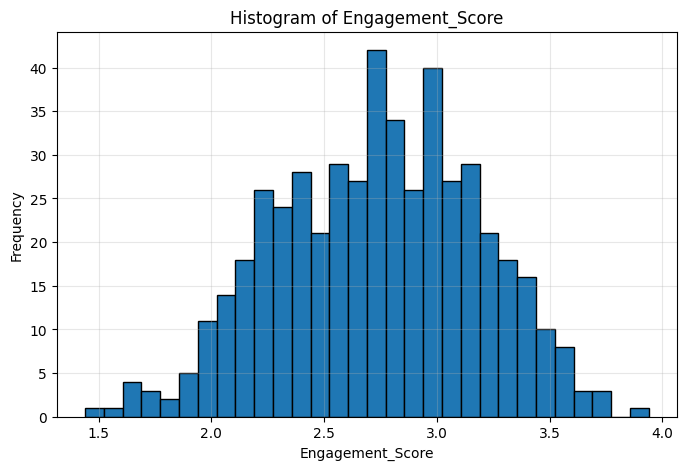

In [292]:
missing_cols_train = summary_train.index.tolist()
plot_histogram(train, missing_cols_train[0], bins=30)

Dall’analisi grafica, la distribuzione di `EngagementScore` non mostra forti distorsioni o outlier evidenti. Per questo motivo, la media campionaria calcolata sul training set viene considerata una scelta ragionevole per sostituire i valori mancanti.

### 4.1.3 Sostituzione dei valori mancanti
Si nota una distribuzione abbastanza simmetrica e il campione è privo di outliers: si sceglie dunque di stimare i missing values tramite media campionaria.

In [293]:
def handle_missing_values_with_mean(df, col):
    df = df.copy()
    value = df[col].mean()
    df[col] = df[col].fillna(value)
    return df

train = handle_missing_values_with_mean(train, col=missing_cols_train[0])


Adesso procediamo a controllare se la funzione ha sostituito correttamente i missing values lasciando un totale di 0 NaN values nel nostro dataset di train.

In [294]:
summary_train = missing_summary(train)
if summary_train is None:
    print('Nessun valore mancante nel train set.')
else:
    print('Colonne con valori mancanti (train):')
    print(summary_train)

Nessun valore mancante nel train set.


**GROSSI DUBBI**

Ci sono dei missing values anche nei test, cosa si fa? (chat dice di usare la stessa strategia scelta nel training) ma
NOTA: i file di train possono essere modificati e usati come si ritiene opportuno. I file di test sono da utilizzare per valutare i modelli e non è possibile rimuovere o aggiungere campioni.
Nel caso si voglia fare anche nel test:

In [295]:
# TEST
'''
summary_test = missing_summary(test)
if summary_test is None:
    print('Nessun valore mancante nel test set.')
else:
    print('\nColonne con valori mancanti (test):')
    print(summary_test)
test = handle_missing_values_with_mean(test, col=missing_cols_train[0])
'''

"\nsummary_test = missing_summary(test)\nif summary_test is None:\n    print('Nessun valore mancante nel test set.')\nelse:\n    print('\nColonne con valori mancanti (test):')\n    print(summary_test)\ntest = handle_missing_values_with_mean(test, col=missing_cols_train[0])\n"

## 4.2 Individuazione dei duplicated data
In questa fase viene verificata la presenza di osservazioni duplicate nel dataset di training.
Le righe duplicate possono alterare la fase di apprendimento, perché aumentano artificialmente il peso di alcune osservazioni rispetto alle altre.
Se non vengono trovate righe duplicate, il dataset può essere mantenuto invariato. Se invece fossero presenti duplicati, questi dovrebbero essere valutati e, se effettivamente ridondanti, rimossi dal training set.

In [296]:
def find_duplicate_rows(df):
    duplicates = df[df.duplicated()]
    if duplicates.empty:
        print("Nessuna riga duplicata trovata.")
        return None
    print(f"Numero di righe duplicate: {duplicates.shape[0]}")
    return duplicates

dup_train = find_duplicate_rows(train)

Nessuna riga duplicata trovata.


## 4.3 Outlier Analysis
In questa sezione viene svolta l’analisi degli outlier presenti nel dataset.

L’obiettivo non è rimuovere automaticamente tutte le osservazioni anomale, ma individuare valori o profili che si discostano dal comportamento generale dei dati. Nel contesto dell’employee attrition, infatti, un dipendente con caratteristiche estreme può rappresentare un caso raro ma realistico, e quindi potenzialmente utile per il modello di classificazione.

L’analisi viene organizzata in tre livelli:
- analisi univariata;
- analisi bivariata;
- analisi multivariata.

Al termine viene proposta una strategia finale di trattamento degli outlier.

### 4.3.1 Analisi univariata degli outlier

L’analisi univariata considera una variabile alla volta.

L’obiettivo è individuare valori estremi rispetto alla distribuzione della singola variabile. Questa fase permette di osservare se esistono valori isolati, code molto lunghe, distribuzioni fortemente asimmetriche o osservazioni molto distanti dal comportamento centrale del dataset.

Per ogni variabile numerica vengono utilizzati strumenti descrittivi e grafici, come statistiche riassuntive, istogrammi e boxplot. I valori estremi individuati vengono segnalati come potenziali outlier, ma non vengono eliminati automaticamente.

#### 4.3.1.1 Selezione delle variabili numeriche

L’analisi univariata viene svolta sulle variabili numeriche del dataset.

Le variabili categoriche non vengono analizzate tramite soglie numeriche, perché non hanno una distribuzione continua su cui applicare criteri come quartili, boxplot o distanza dalla media.

In questa fase vengono quindi selezionati gli attributi numerici più rilevanti per descrivere il profilo del dipendente.

In [297]:
numeric_values = train.select_dtypes(include=['int64', 'float64'])
numeric_values = numeric_values.drop(columns=['Attrition'])
print(numeric_values.head())

   Age  DistanceFromHome  Education  JobLevel  MonthlyIncome  DailyRate  \
0   31                 1          3         2           8674        849   
1   38                12          3         4           4677        955   
2   40                14          4         2          16959        390   
3   39                 7          4         2           5404       1017   
4   34                 5          2         2           2446        996   

   HourlyRate  PercentSalaryHike  StockOptionLevel  JobSatisfaction  ...  \
0          67                 13                 0                4  ...   
1          85                 24                 0                1  ...   
2          42                 22                 0                3  ...   
3          72                 17                 1                2  ...   
4          68                 19                 3                4  ...   

   TotalWorkingYears  YearsAtCompany  YearsInCurrentRole  \
0                  7            

Per ottimizzare l'analisi sulle variabili numeriche dividiamo il dataset di variabili numeriche in due ulteriori dataset rappresentanti le variabili continue e le variabili discrete.


In [298]:
discrete_features = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance"
]

continuous_features = [col for col in numeric_values.columns if col not in discrete_features]


continuous_variables = numeric_values[continuous_features]
discrete_variables = numeric_values[discrete_features]

print(f'the continuos variables are: \n{continuous_variables}\n')
print(f'the discrete variables are: \n{discrete_variables}')

the continuos variables are: 
     Age  DistanceFromHome  MonthlyIncome  DailyRate  HourlyRate  \
0     31                 1           8674        849          67   
1     38                12           4677        955          85   
2     40                14          16959        390          42   
3     39                 7           5404       1017          72   
4     34                 5           2446        996          68   
..   ...               ...            ...        ...         ...   
595   50                 1           2695        478          63   
596   26                 1           2046        750          43   
597   32                12           2731        431          54   
598   42                16           5906       1099          50   
599   56                13           1914       1161          62   

     PercentSalaryHike  TotalWorkingYears  YearsAtCompany  YearsInCurrentRole  \
0                   13                  7              16               

#### 4.3.1.2 Statistiche descrittive

Per ogni variabile numerica vengono osservati minimo, massimo, media, mediana, deviazione standard e quartili.
Queste statistiche permettono di comprendere la distribuzione della variabile e di individuare eventuali valori sospetti.
In particolare, valori massimi o minimi molto distanti dai quartili possono suggerire la presenza di potenziali outlier.

In [299]:
def continuous_variable_analysis(df):
    for col in df.columns:
        if df[col].dtype not in ['int64', 'float64']:
            print(f'Analisi non fattibile, la feature {col} è non numerica.')
            return
        else:
            continue
    
    summary = []

    for col in df.columns:
        summary.append({
            'Variable': col,
            'Minimo': df[col].min(),
            'Q1': df[col].quantile(0.25),
            'Media': df[col].mean(),
            'Q3': df[col].quantile(0.75),
            'Massimo': df[col].max(),
            'Mediana': df[col].median(),
            'Dev. Std.': df[col].std()
            
        })
    
    return pd.DataFrame(summary)


In [300]:
def discrete_variable_analysis(df):
    for col in df.columns:
        if df[col].dtype not in ['int64', 'float64']:
            print(f'Analisi non fattibile, la feature {col} è non numerica.')
            return
        else:
            continue
    
    summary = []

    for col in df.columns:
        summary.append({
            'Variabile': col,
            'Minimo': df[col].min(),
            'Massimo': df[col].max(),
            'Moda': df[col].mode()[0],
            'Frequenza assoluta': df[col].value_counts().max(),
            'Frequenza relativa (%)': df[col].value_counts(normalize=True).max() * 100
        })

    return pd.DataFrame(summary)


In [301]:
continuous_analysis = continuous_variable_analysis(continuous_variables)
print(continuous_analysis)

                   Variable    Minimo         Q1        Media          Q3  \
0                       Age    18.000    31.0000    37.078333    43.00000   
1          DistanceFromHome     1.000     3.0000     8.968333    13.00000   
2             MonthlyIncome  1009.000  3194.7500  5937.645000  7562.00000   
3                 DailyRate   102.000   495.5000   843.655000  1190.75000   
4                HourlyRate    30.000    49.0000    64.473333    81.00000   
5         PercentSalaryHike    11.000    14.0000    17.448333    21.00000   
6         TotalWorkingYears     0.000     6.0000    11.286667    16.00000   
7            YearsAtCompany     0.000     3.0000     7.725000    11.25000   
8        YearsInCurrentRole     0.000     2.0000     4.405000     6.25000   
9   YearsSinceLastPromotion     0.000     1.0000     2.378333     3.00000   
10     YearsWithCurrManager     0.000     2.0000     4.453333     7.00000   
11       NumCompaniesWorked     0.000     1.0000     3.555000     5.00000   

In [302]:
discrete_analysis = discrete_variable_analysis(discrete_variables)
print(discrete_analysis)

                  Variabile  Minimo  Massimo  Moda  Frequenza assoluta  \
0                 Education       1        5     3                 227   
1   EnvironmentSatisfaction       1        4     4                 174   
2            JobInvolvement       1        4     3                 371   
3                  JobLevel       1        5     1                 204   
4           JobSatisfaction       1        4     4                 193   
5         PerformanceRating       3        4     3                 501   
6  RelationshipSatisfaction       1        4     4                 190   
7          StockOptionLevel       0        3     1                 261   
8           WorkLifeBalance       1        4     3                 346   

   Frequenza relativa (%)  
0               37.833333  
1               29.000000  
2               61.833333  
3               34.000000  
4               32.166667  
5               83.500000  
6               31.666667  
7               43.500000  
8      

#### 4.3.1.3 Istogrammi e distribuzioni empiriche

Gli istogrammi vengono utilizzati per osservare la forma della distribuzione delle variabili numeriche.

Questa analisi permette di capire se una variabile è simmetrica, asimmetrica, concentrata in un intervallo ristretto oppure caratterizzata da code lunghe.

La presenza di valori isolati nelle code della distribuzione può indicare potenziali outlier, ma deve essere interpretata in base al significato della variabile.
 
 
**Variabili continue**

In [303]:
import math

def histogram_visualization(df, bins=30):
    n_features = len(df.columns)
    if n_features == 0:
        print(f'Non ci sono feature da plottare')
        return
    
    n_cols = 3
    n_rows = math.ceil(n_features/n_cols)
    
    fig_width = 5 * n_cols
    fig_height = 3 * n_rows

    plt.figure(figsize=(fig_width, fig_height))
        
    for i, col in enumerate(df,1):
        plt.subplot(n_rows, n_cols, i)
        plt.hist(df[col], bins= bins)
        plt.title(col)
        plt.xlabel(col)

    plt.tight_layout()
    plt.show()

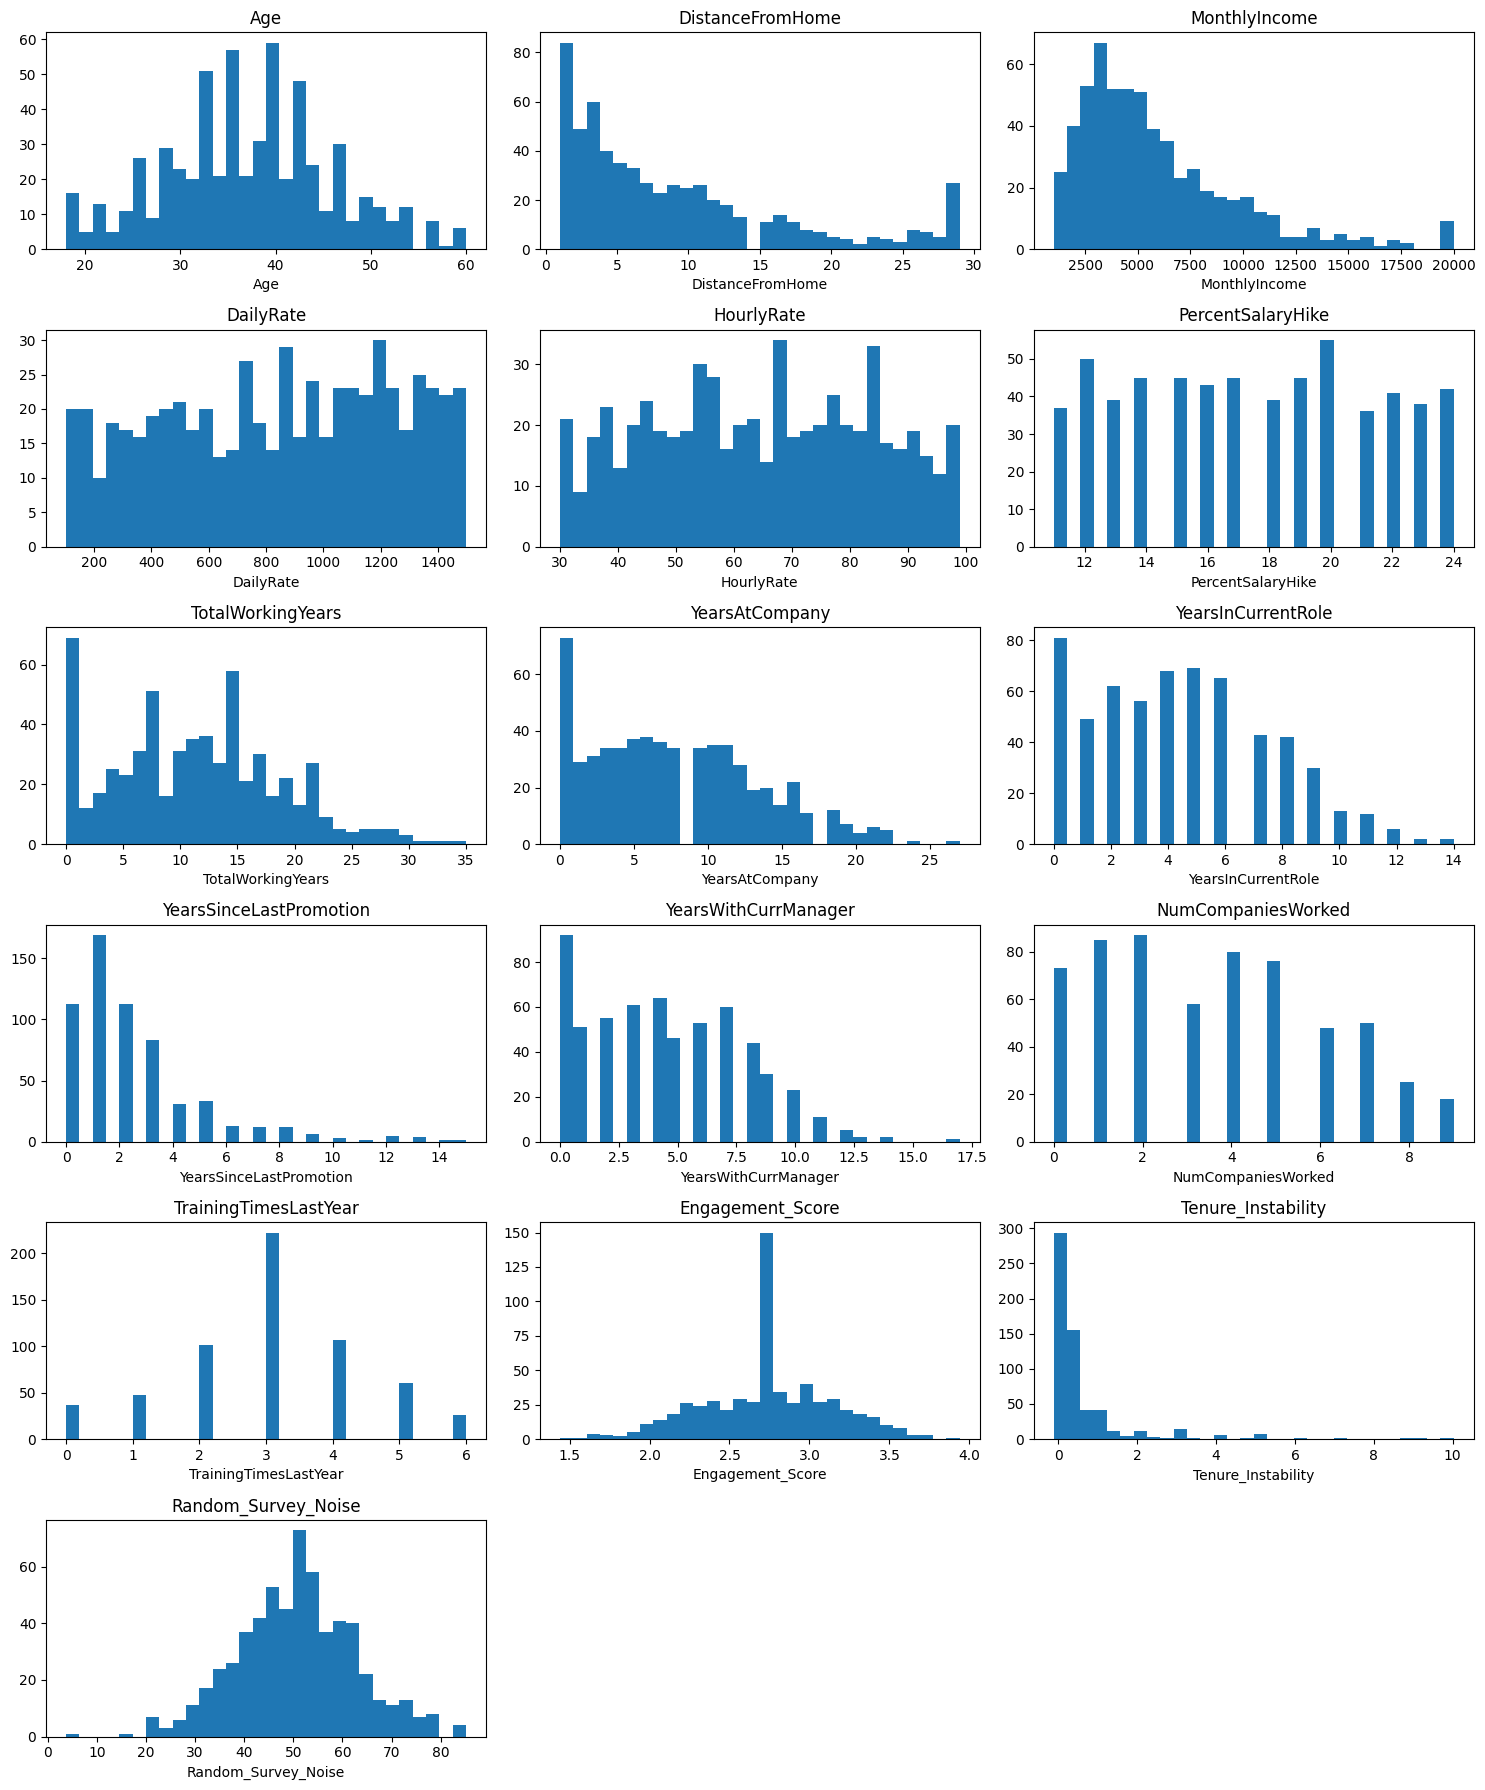

In [304]:
histogram_visualization(continuous_variables)

**Variabili Discrete**

In [305]:
def discrete_variables_percentage_visualization(df, n_cols=3):

    n_features = len(df.columns)

    if n_features == 0:
        print("Non ci sono variabili discrete da plottare")
        return

    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows)
    )

    axes = axes.flatten()

    for i, col in enumerate(df.columns):

        percentages = df[col].value_counts(normalize=True).sort_index() * 100

        axes[i].bar(percentages.index, percentages.values)

        axes[i].set_title(col, pad=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Percentage (%)")
        axes[i].set_xticks(percentages.index)

        for x, y in zip(percentages.index, percentages.values):
            axes[i].text(x, y, f"{y:.1f}%", ha="center", va="bottom")

    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)

    plt.subplots_adjust(hspace=0.7, wspace=0.3)
    plt.tight_layout()
    plt.show()

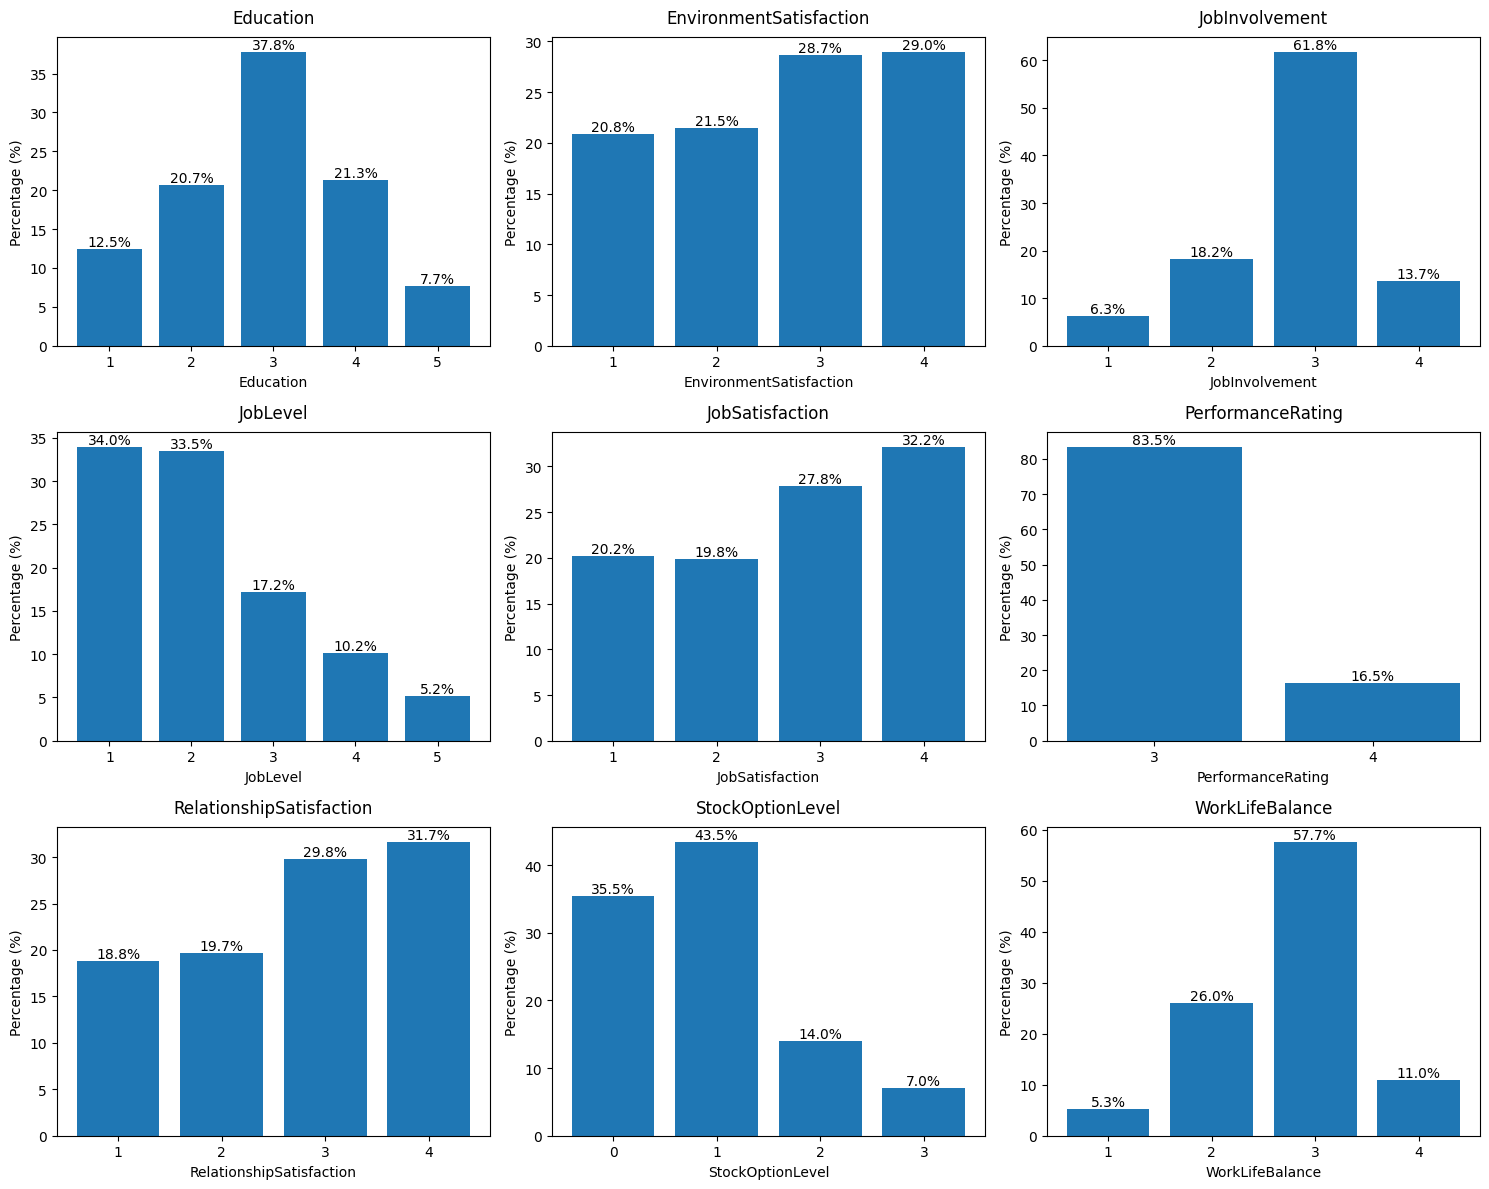

In [306]:
discrete_variables_percentage_visualization(discrete_variables)

L’analisi grafica permette di distinguere chiaramente il comportamento delle variabili continue da quello delle variabili discrete/ordinali.

Per le variabili discrete e ordinali, i bar plot percentuali mostrano che alcune feature sono concentrate su pochi livelli dominanti. In particolare, `JobInvolvement` e `WorkLifeBalance` sono fortemente concentrate sul livello 3, mentre `PerformanceRating` presenta una variabilità molto limitata, con la maggior parte delle osservazioni sul valore 3. Questo suggerisce che alcune variabili potrebbero avere un potere descrittivo ridotto nell’analisi univariata, poiché distinguono poco tra i dipendenti.

Altre variabili, come `EnvironmentSatisfaction`, `JobSatisfaction` e `RelationshipSatisfaction`, risultano invece distribuite in modo più equilibrato tra i livelli, pur con una maggiore presenza di valori medio-alti. `StockOptionLevel` è concentrata soprattutto sui livelli 0 e 1, indicando che i livelli più alti di stock option sono meno frequenti nel dataset.

Per le variabili continue, gli istogrammi mostrano distribuzioni differenti. `Age` è concentrata principalmente tra 30 e 45 anni, mentre `DailyRate` e `HourlyRate` appaiono abbastanza distribuite lungo il loro intervallo. Al contrario, `MonthlyIncome`, `DistanceFromHome`, `TotalWorkingYears`, `YearsAtCompany`, `YearsSinceLastPromotion` e `YearsWithCurrManager` mostrano distribuzioni asimmetriche verso destra, con molti valori bassi o intermedi e pochi valori elevati.

Queste code verso destra non indicano necessariamente errori: in un dataset HR possono rappresentare profili realistici, come dipendenti senior, manager o persone con lunga permanenza in azienda. Per questo motivo, i valori estremi individuati graficamente non vengono rimossi automaticamente, ma saranno analizzati successivamente tramite metodo IQR.

#### 4.3.1.4 Univariate Outlier analysis tramite metodo IQR

Dopo l’analisi descrittiva e grafica, viene applicato il metodo IQR alle variabili numeriche ***continue*** per individuare potenziali valori anomali.

Il metodo IQR utilizza il primo quartile, il terzo quartile e l’intervallo interquartile per definire due soglie:

Lower Bound = Q1 - 1.5 × IQR  
Upper Bound = Q3 + 1.5 × IQR

I valori al di sotto della soglia inferiore o al di sopra della soglia superiore vengono identificati come potenziali outlier. Tuttavia, in questa fase non vengono rimossi automaticamente: vengono solo segnalati per una successiva interpretazione. Infatti, in un dataset HR, valori elevati di variabili come MonthlyIncome, TotalWorkingYears o YearsAtCompany possono rappresentare profili reali di dipendenti senior, non necessariamente errori.

In [307]:
def IQR(df):
    
    summary = []

    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3-Q1

        upper_bound = Q3 + 1.5*IQR
        lower_bound = Q1 - 1.5*IQR

        sus = df[(df[col]<lower_bound) | (df[col]>upper_bound)]

        summary.append({
            'Variable': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            '# Possible Outliers': len(sus),
            '# Total Elements': len(df),
            'Possible Outliers': sus[col].tolist(),
            'Possible Outliers (%)': round(len(sus[col])/len(df) * 100, 2)

        })

    return pd.DataFrame(summary)

In [308]:
IQR_analysis = IQR(continuous_variables)
mask = IQR_analysis['# Possible Outliers']>0
IQR_analysis = IQR_analysis[mask]
print(IQR_analysis)

                   Variable         Q1          Q3         IQR  Lower Bound  \
1          DistanceFromHome     3.0000    13.00000    10.00000   -12.000000   
2             MonthlyIncome  3194.7500  7562.00000  4367.25000 -3356.125000   
6         TotalWorkingYears     6.0000    16.00000    10.00000    -9.000000   
7            YearsAtCompany     3.0000    11.25000     8.25000    -9.375000   
8        YearsInCurrentRole     2.0000     6.25000     4.25000    -4.375000   
9   YearsSinceLastPromotion     1.0000     3.00000     2.00000    -2.000000   
10     YearsWithCurrManager     2.0000     7.00000     5.00000    -5.500000   
13         Engagement_Score     2.4900     2.98250     0.49250     1.751250   
14       Tenure_Instability     0.0680     0.56375     0.49575    -0.675625   
15      Random_Survey_Noise    42.8825    58.63000    15.74750    19.261250   

     Upper Bound  # Possible Outliers  # Total Elements  \
1      28.000000                   27               600   
2   14112.87

Il metodo IQR ha individuato potenziali outlier in diverse variabili continue. Le variabili con il maggior numero di valori sospetti sono `Tenure_Instability`, `YearsSinceLastPromotion`, `DistanceFromHome` e `MonthlyIncome`.

Tuttavia, questi valori non vengono rimossi automaticamente. In un dataset HR, valori estremi possono rappresentare profili realistici, come dipendenti con reddito elevato, lunga esperienza, molti anni senza promozione o alta instabilità di carriera. Per questo motivo, la IQR viene utilizzata solo come metodo di segnalazione preliminare.

I potenziali outlier vengono quindi analizzati successivamente tramite confronti bivariati e controlli logici, per verificare se siano coerenti con altre variabili del profilo del dipendente.

### 4.3.2 Analisi bivariata degli outlier

Dopo aver individuato i potenziali outlier tramite il metodo IQR, l’analisi prosegue con una fase bivariata. L’obiettivo non è eliminare automaticamente i valori estremi, ma capire se questi valori siano realmente sospetti oppure se possano essere spiegati dal comportamento di altre variabili del dataset.

In un dataset HR, infatti, un valore estremo non rappresenta necessariamente un errore. Ad esempio, un reddito molto elevato può essere coerente con un alto livello lavorativo, molti anni di esperienza o un ruolo manageriale. Allo stesso modo, un numero elevato di anni senza promozione può rappresentare una situazione aziendale reale e potenzialmente rilevante per l’analisi dell’attrition.

Per questo motivo, i potenziali outlier vengono analizzati confrontandoli con variabili logicamente o statisticamente correlate. Questa fase permette di distinguere tra valori estremi plausibili, che devono essere mantenuti, e possibili incoerenze che potrebbero richiedere ulteriori controlli.

#### 4.3.2.1 Analisi di correlazione

Come primo step dell’analisi bivariata, vengono calcolate le matrici di correlazione tra le variabili numeriche del dataset.

In particolare, vengono considerate due misure: la correlazione di Pearson e la correlazione di Spearman. La correlazione di Pearson misura relazioni lineari tra variabili numeriche continue o quasi continue, mentre la correlazione di Spearman si basa sui ranghi ed è più adatta anche in presenza di variabili ordinali codificate numericamente.

Questa analisi viene utilizzata come strumento esplorativo per individuare coppie di variabili potenzialmente associate e selezionare quali relazioni approfondire nelle successive visualizzazioni bivariate.

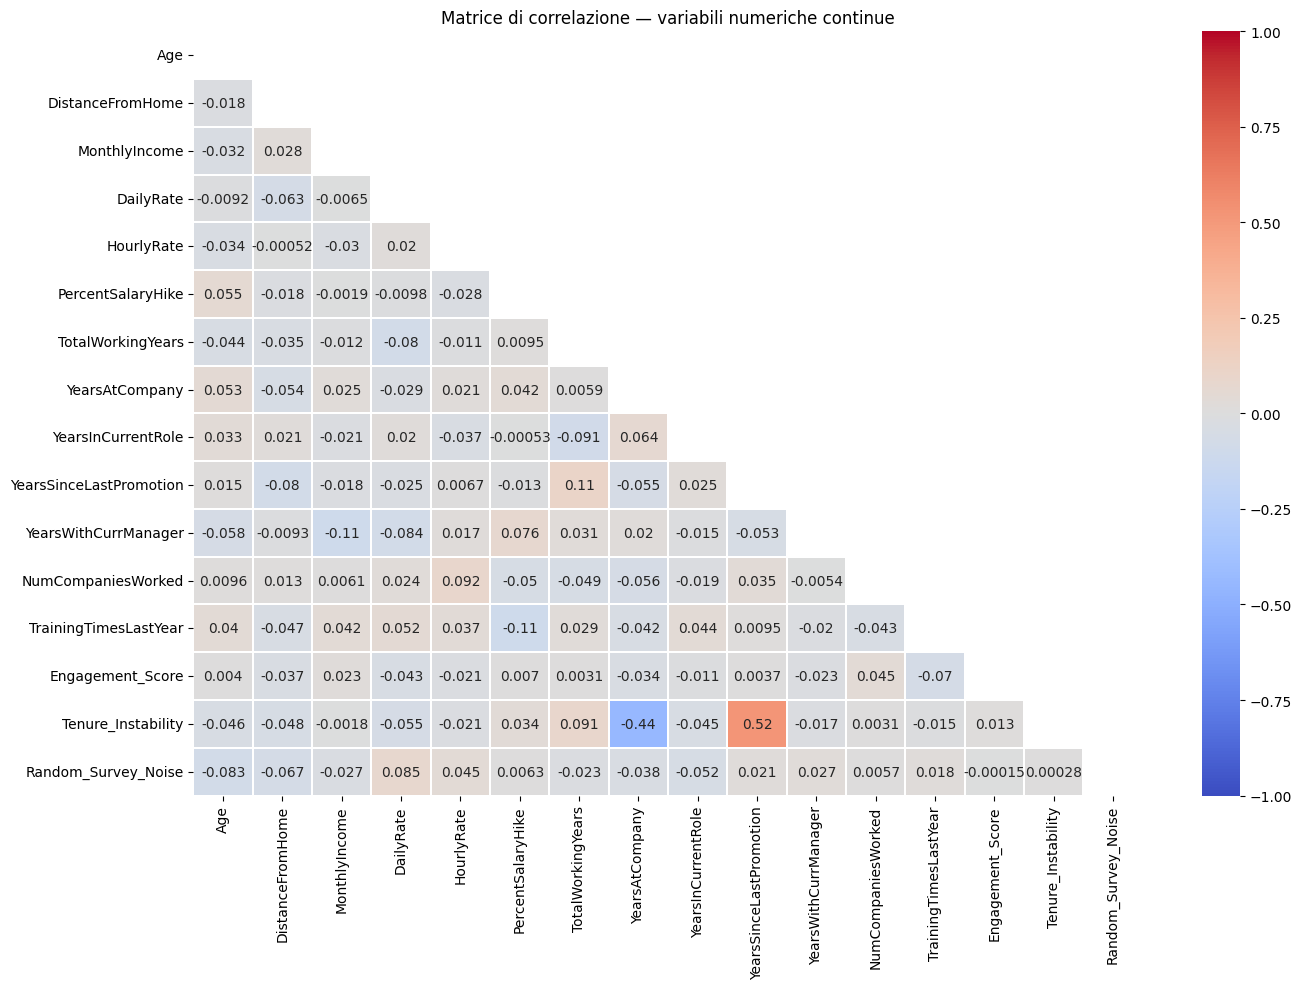

In [309]:
import seaborn as sns

corr_matrix_pearson = continuous_variables.corr(method='pearson')

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix_pearson, dtype=bool))
sns.heatmap(corr_matrix_pearson, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=True, vmin=-1, vmax=1)
plt.title('Matrice di correlazione — variabili numeriche continue')
plt.tight_layout()
plt.show()

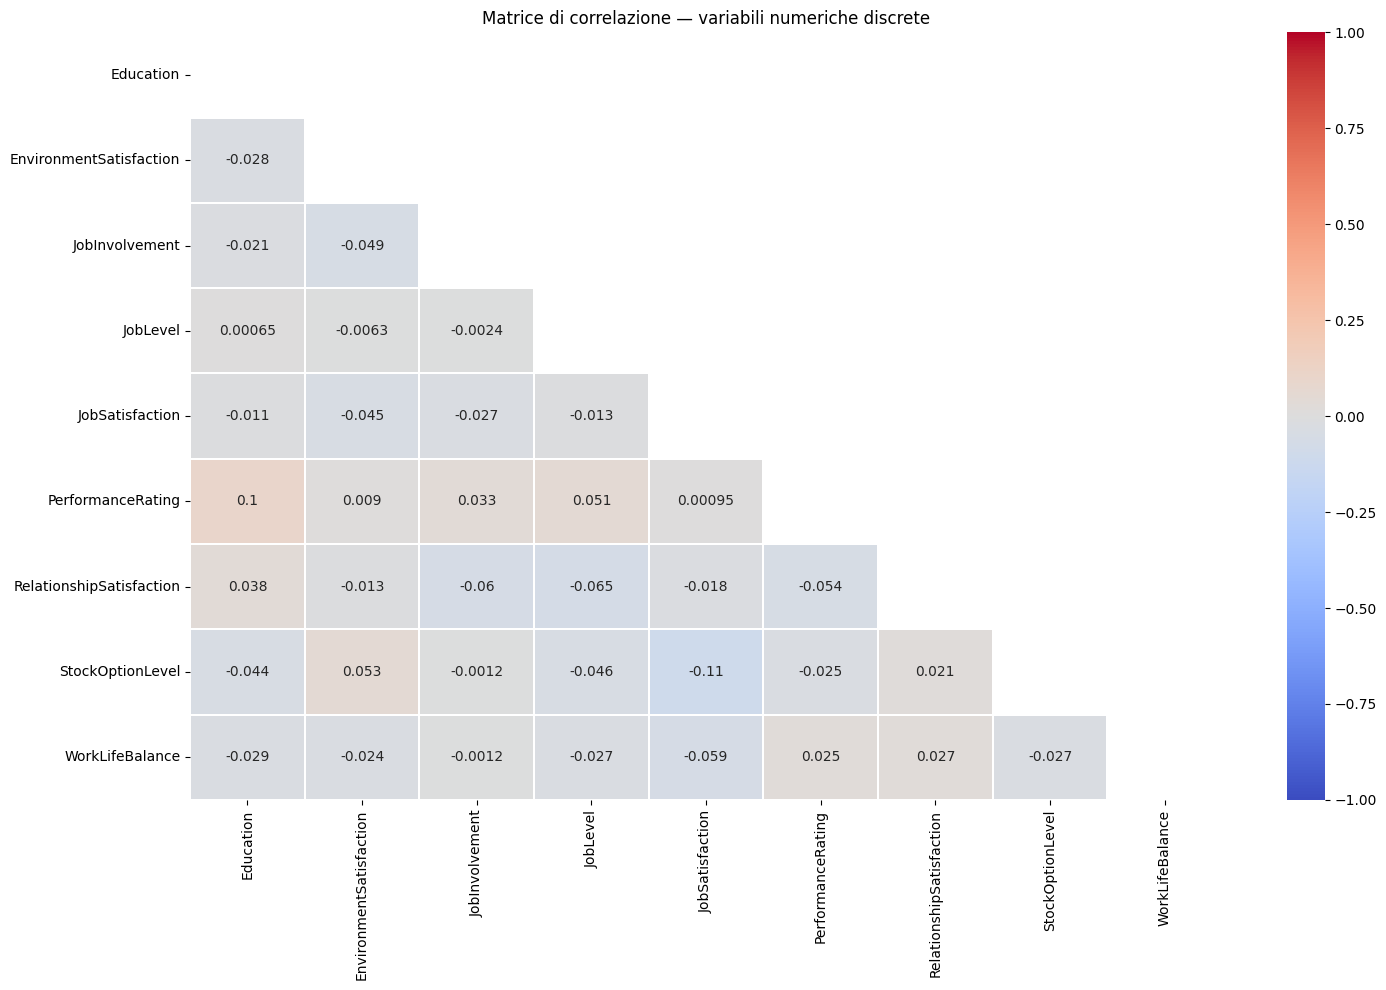

In [310]:
corr_matrix_spearman = discrete_variables.corr(method='spearman')
plt.figure(figsize=(15, 10))
mask = np.triu(np.ones_like(corr_matrix_spearman, dtype=bool))
sns.heatmap(corr_matrix_spearman, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=True, vmin=-1, vmax=1)
plt.title('Matrice di correlazione — variabili numeriche discrete')
plt.tight_layout()
plt.show()



Dalle due matrici separate emerge che la maggior parte delle correlazioni è molto debole. Questo indica che, considerando separatamente variabili continue e variabili discrete/ordinali, non sembrano esserci forti problemi di ridondanza interna tra le feature.

Per le variabili continue, le relazioni più evidenti riguardano `Tenure_Instability`. In particolare, questa variabile mostra una correlazione positiva con `YearsSinceLastPromotion` e una correlazione negativa con `YearsAtCompany`. Questo risultato è coerente con il significato della feature: valori più elevati di instabilità tendono a comparire quando il tempo dall’ultima promozione è alto oppure quando la permanenza in azienda è relativamente bassa.

Le altre variabili continue mostrano correlazioni generalmente vicine a zero. Questo suggerisce che feature come `Age`, `MonthlyIncome`, `DistanceFromHome`, `DailyRate`, `HourlyRate` e `PercentSalaryHike` descrivono aspetti differenti del profilo del dipendente e non risultano fortemente associate tra loro in questa prima analisi.

Per le variabili discrete e ordinali, le correlazioni risultano ancora più deboli. Variabili come `Education`, `JobSatisfaction`, `EnvironmentSatisfaction`, `JobInvolvement`, `StockOptionLevel` e `WorkLifeBalance` sembrano quindi catturare dimensioni diverse del dataset. Non emergono relazioni forti tali da suggerire una rimozione immediata di variabili per ridondanza.

Queste prime matrici forniscono una lettura più controllata delle relazioni interne ai due gruppi di variabili. Successivamente viene calcolata anche una matrice generale, includendo tutte le variabili numeriche, per osservare eventuali relazioni tra variabili continue e variabili discrete/ordinali.

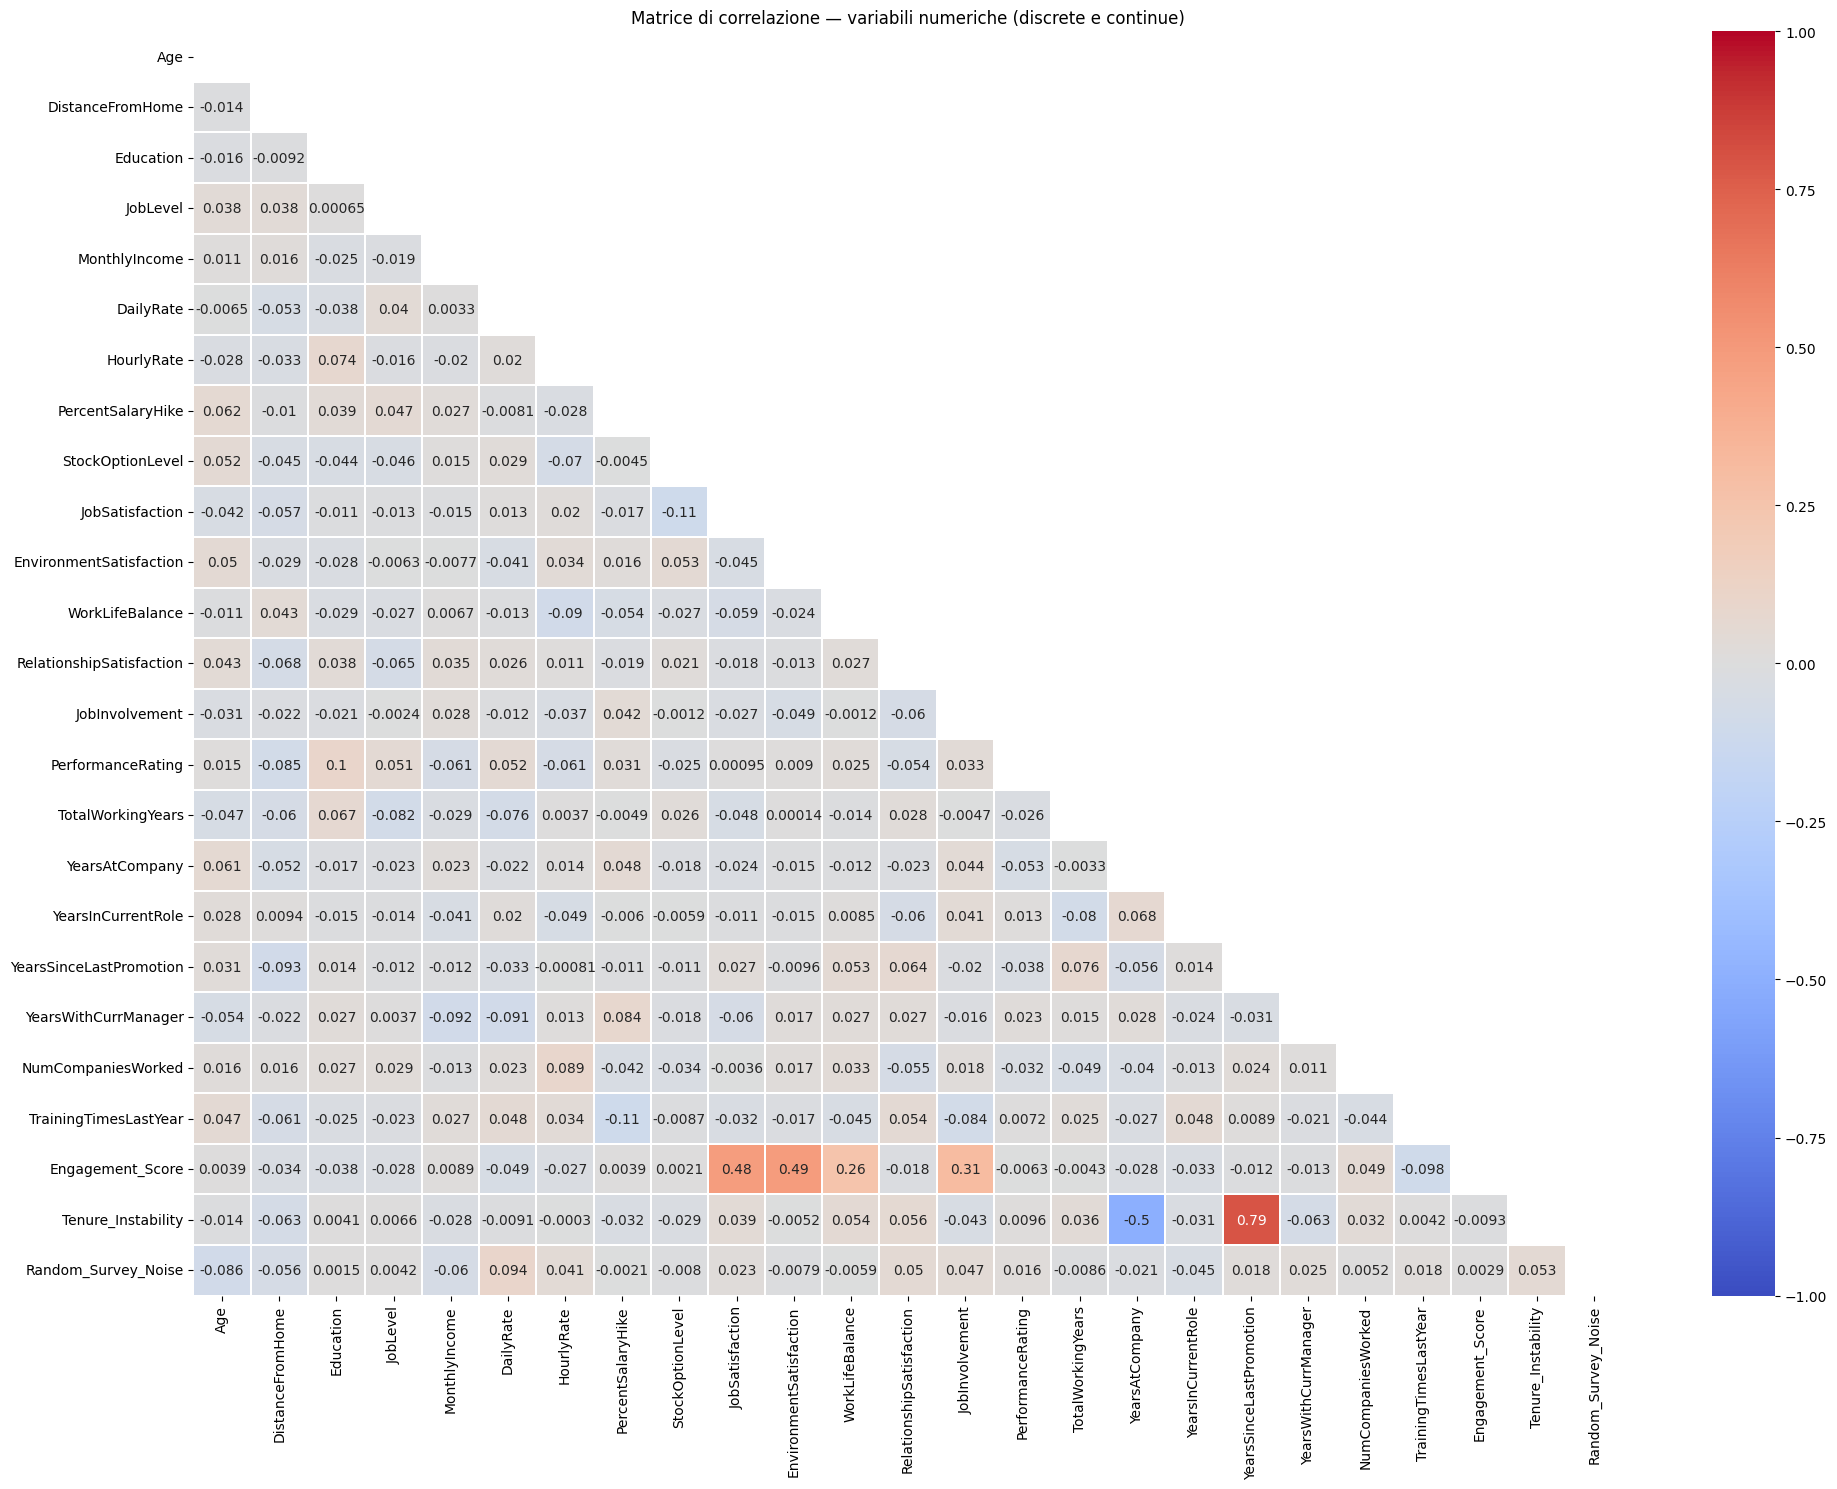

In [311]:
corr_matrix_all = numeric_values.corr(method='spearman')
plt.figure(figsize=(20, 15))
mask = np.triu(np.ones_like(corr_matrix_all, dtype=bool))
sns.heatmap(corr_matrix_all, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=True, vmin=-1, vmax=1)
plt.title('Matrice di correlazione — variabili numeriche (discrete e continue)')
plt.tight_layout()
plt.show()

Dalla matrice generale, calcolata includendo sia variabili continue sia variabili discrete/ordinali codificate numericamente, emerge che la maggior parte delle correlazioni rimane debole. Questo conferma che molte feature descrivono aspetti diversi del profilo del dipendente e non risultano fortemente ridondanti tra loro.

Le relazioni più evidenti riguardano alcune variabili specifiche del dataset. In particolare, `Engagement_Score` mostra una correlazione positiva con variabili legate alla soddisfazione e al coinvolgimento, come `JobSatisfaction`, `EnvironmentSatisfaction`, `JobInvolvement` e `WorkLifeBalance`. Questo risultato è coerente con il significato della variabile, poiché un maggiore livello di engagement dovrebbe essere associato a valutazioni più positive su soddisfazione, coinvolgimento e bilanciamento vita-lavoro.

Anche `Tenure_Instability` mostra relazioni evidenti con alcune variabili legate alla carriera aziendale. In particolare, risulta positivamente correlata con `YearsSinceLastPromotion` e negativamente correlata con `YearsAtCompany`. Questo suggerisce che valori più elevati di instabilità possono essere associati a situazioni in cui il dipendente ha una lunga distanza dall’ultima promozione oppure una permanenza aziendale relativamente bassa.

Nel complesso, la matrice generale non evidenzia correlazioni problematiche tali da richiedere una rimozione immediata di variabili per ridondanza. Le correlazioni più alte appaiono interpretabili in modo coerente con il significato delle variabili HR. Per questo motivo, le feature vengono mantenute per le analisi successive, mentre le relazioni più rilevanti verranno eventualmente approfondite tramite grafici bivariati mirati.

#### 4.3.2.2 Selezione dei controlli bivariati sugli outlier

Le matrici di correlazione non vengono utilizzate per eliminare variabili o osservazioni, ma per guidare l’analisi successiva. In particolare, aiutano a individuare quali variabili possono essere confrontate tra loro per interpretare i potenziali outlier individuati con il metodo IQR.

La scelta delle coppie da analizzare non si basa solo sulla correlazione statistica, ma anche sulla coerenza logica tra le variabili. Alcune relazioni, infatti, devono essere valutate in base al significato HR delle feature. Ad esempio, un valore elevato di `MonthlyIncome` può essere plausibile se associato a un alto `JobLevel`, molti anni di esperienza o un ruolo manageriale. Allo stesso modo, variabili come `YearsInCurrentRole`, `YearsWithCurrManager` e `YearsSinceLastPromotion` devono essere interpretate rispetto a `YearsAtCompany`.

Per questo motivo, gli outlier vengono approfonditi tramite grafici bivariati mirati e controlli di coerenza.

I principali controlli bivariati scelti sono:

| Variabile con outlier | Variabili di confronto | Motivazione |
|---|---|---|
| `DistanceFromHome` | Nessuna variabile di coerenza interna diretta | `DistanceFromHome` presenta diversi valori estremi, ma una distanza elevata non può essere giudicata incoerente usando altre variabili del dataset. Non esiste una feature che dica quale distanza “dovrebbe” avere un dipendente. Per questo motivo, i valori elevati vengono mantenuti e saranno eventualmente interpretati nella successiva analisi rispetto al target. |
| `MonthlyIncome` | `JobLevel`, `JobRole`, `TotalWorkingYears` | I valori elevati di reddito devono essere interpretati rispetto al profilo professionale. Un reddito alto è plausibile se associato a un livello lavorativo elevato, a ruoli più senior o a molti anni di esperienza. La correlazione generale non è molto forte, ma questi confronti sono logicamente rilevanti nel contesto HR. |
| `YearsSinceLastPromotion` | `YearsAtCompany`, `JobLevel`, `Tenure_Instability` | Molti anni senza promozione possono essere plausibili se il dipendente è da molti anni in azienda oppure si trova già a un livello lavorativo alto. Inoltre, dalla matrice generale emerge una relazione forte con `Tenure_Instability`, quindi il confronto aiuta a capire se i valori estremi sono coerenti con una situazione di possibile stagnazione o instabilità di carriera. |
| `Tenure_Instability` | `YearsSinceLastPromotion`, `YearsAtCompany` | `Tenure_Instability` è la variabile con la percentuale più alta di possibili outlier. Dalla matrice di correlazione emerge una relazione positiva forte con `YearsSinceLastPromotion` e una relazione negativa con `YearsAtCompany`. Per questo motivo, i suoi valori estremi vengono interpretati rispetto al tempo dall’ultima promozione e alla permanenza complessiva in azienda. |

#### Controlli logici di coerenza

Prima di procedere con l'analisi dei controlli bivariati su gli item ritenuti piu problematici dai risultati dell'analisi IQR insieme alle feature con cui sono piu correlate, vengono eseguiti alcuni controlli logici tra variabili temporalmente collegate. Questi controlli non servono a individuare valori estremi dal punto di vista statistico, ma a verificare la presenza di combinazioni non plausibili nel contesto HR.

A differenza della IQR, che segnala valori distanti dalla distribuzione centrale, i controlli logici verificano vincoli che dovrebbero essere rispettati per costruzione. Ad esempio, gli anni trascorsi nel ruolo attuale non dovrebbero superare gli anni totali passati in azienda.a

In [312]:
logical_checks = {
    "YearsInCurrentRole > YearsAtCompany": train[
        train["YearsInCurrentRole"] > train["YearsAtCompany"]
    ],
    "YearsWithCurrManager > YearsAtCompany": train[
        train["YearsWithCurrManager"] > train["YearsAtCompany"]
    ],
    "YearsSinceLastPromotion > YearsAtCompany": train[
        train["YearsSinceLastPromotion"] > train["YearsAtCompany"]
    ],
    "YearsAtCompany > TotalWorkingYears": train[
        train["YearsAtCompany"] > train["TotalWorkingYears"]
    ]
}

for check_name, result in logical_checks.items():
    print(f'{check_name}: {len(result)} sus item')

YearsInCurrentRole > YearsAtCompany: 189 sus item
YearsWithCurrManager > YearsAtCompany: 181 sus item
YearsSinceLastPromotion > YearsAtCompany: 109 sus item
YearsAtCompany > TotalWorkingYears: 199 sus item


dataset da buttare

#### 4.3.2.3 Analisi dei controlli bivariati sugli outlier
**Funzioni per il controllo bivariato**

In [313]:
def get_IQR_data(df, column):

    if df[column].dtypes not in ['int64', 'float64']:
        print('Imposssibile applicare analisi IQR su questo dataset')
        return
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1

    lower_bound  = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    mask = (df[column]<lower_bound) | (df[column] > upper_bound)

    return mask, lower_bound, upper_bound

In [314]:
def scatters(df, x_col, sus):

    mask, lower_bound, upper_bound = get_IQR_data(df, sus)

    plt.figure(figsize=(12,7))

    plt.scatter(
        df[x_col],
        df[sus],
        alpha= 0.5,
        label= 'Normal Observations'
    )

    plt.scatter(
        df.loc[mask, x_col],
        df.loc[mask, sus],
        marker="x",
        s= 80,
        label= 'IQR Outliers'
    )

    plt.axhline(upper_bound, linestyle="--", label="IQR upper bound")
    plt.axhline(lower_bound, linestyle="--", label='IQR lower bound')

    plt.xticks(rotation=90, ha="right")

    plt.title(f'{sus} vs. {x_col}')
    plt.xlabel(x_col)
    plt.ylabel(sus)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 0.8))
    plt.tight_layout()
    plt.show()

**1) Montly Income**

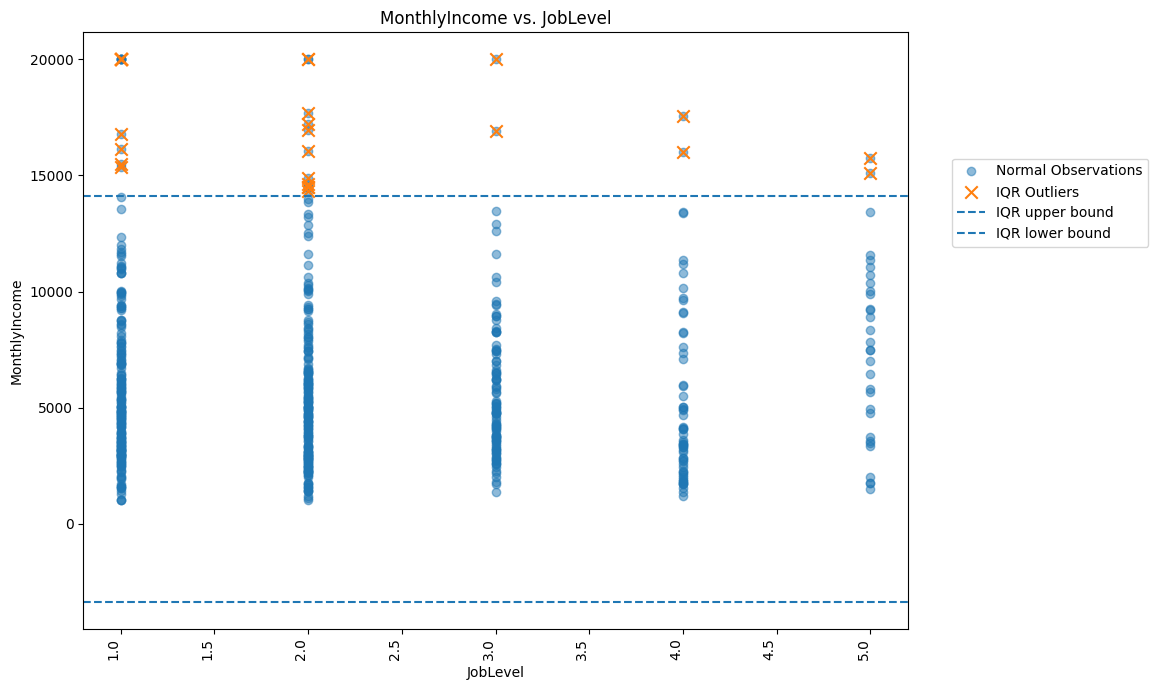

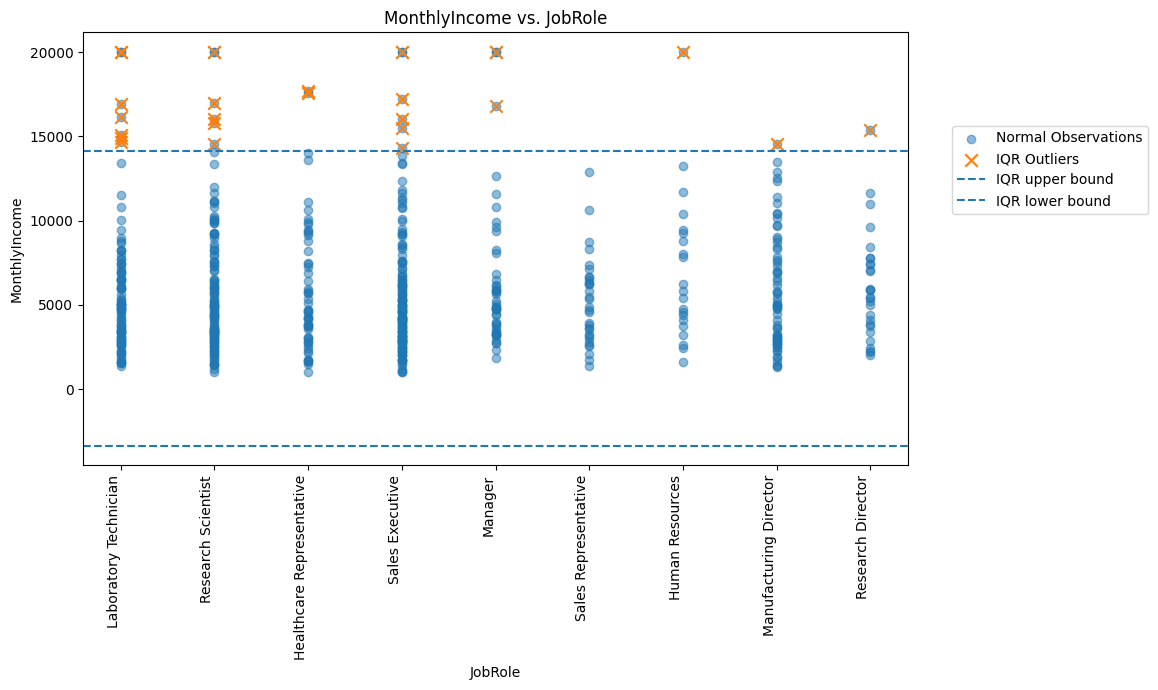

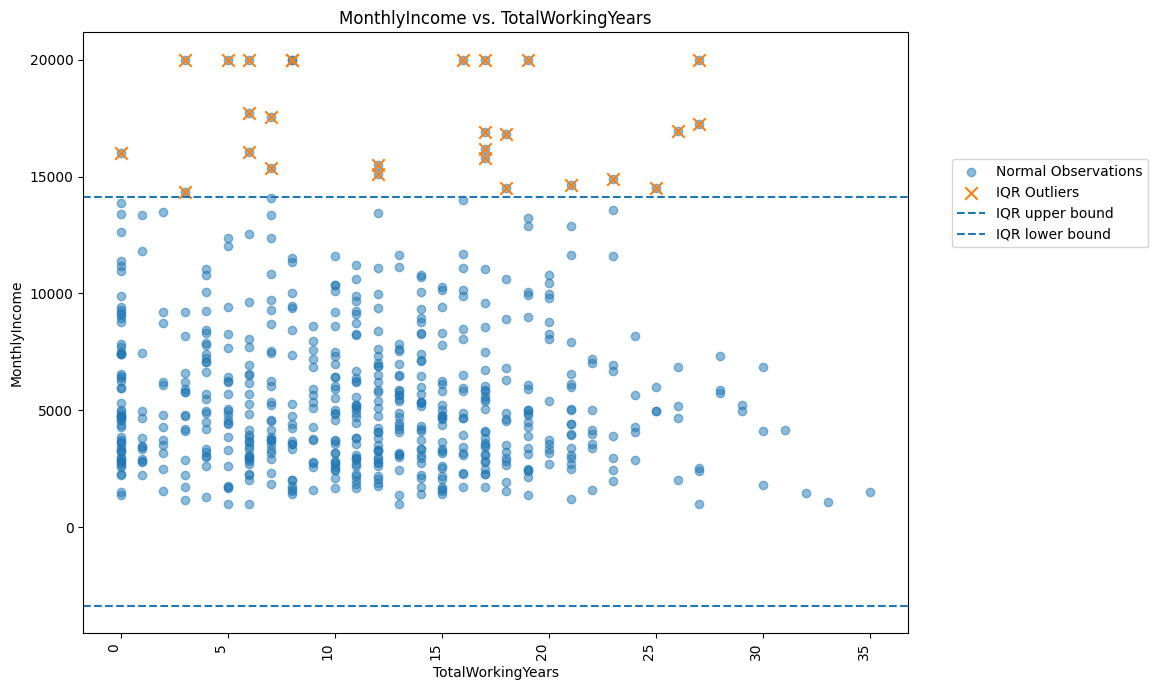

In [315]:
sus = 'MonthlyIncome'
checks = ['JobLevel', 'JobRole', 'TotalWorkingYears']

for column in checks:
    scatters(train, column, sus)



L’analisi bivariata di `MonthlyIncome` mostra che i valori individuati come outlier dal metodo IQR non possono essere spiegati completamente da una sola variabile di contesto.

Nel confronto con `JobLevel`, ci si aspetterebbe che i redditi più elevati siano concentrati soprattutto nei livelli lavorativi più alti. Tuttavia, dal grafico si osserva che alcuni outlier di `MonthlyIncome` compaiono anche in livelli bassi o intermedi. Questo indica che `JobLevel`, da solo, non è sufficiente per giustificare tutti i valori estremi di reddito.

Il confronto con `JobRole` mostra che gli outlier sono distribuiti tra diversi ruoli aziendali, non solo tra posizioni tipicamente senior o manageriali. Anche questo suggerisce che il ruolo lavorativo contribuisce all’interpretazione dei redditi elevati, ma non permette da solo di classificare automaticamente tali valori come plausibili o anomali.

Infine, il grafico `MonthlyIncome` vs `TotalWorkingYears` mostra che alcuni redditi elevati sono associati a molti anni di esperienza, ma altri compaiono anche per dipendenti con esperienza più limitata. Questo rende necessario mantenere un’interpretazione prudente: i valori estremi di `MonthlyIncome` non vengono rimossi automaticamente, ma vengono considerati profili particolari che potrebbero richiedere ulteriori verifiche o essere mantenuti come casi rari ma informativi per il modello.

**2) Years since last Promotion**

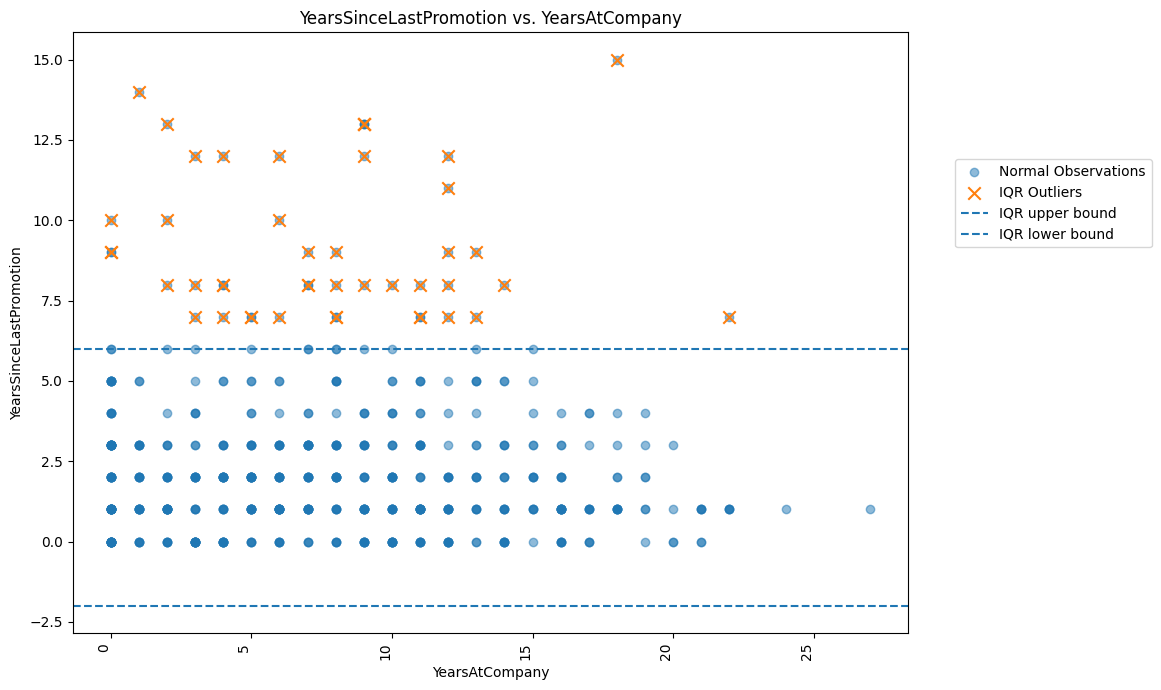

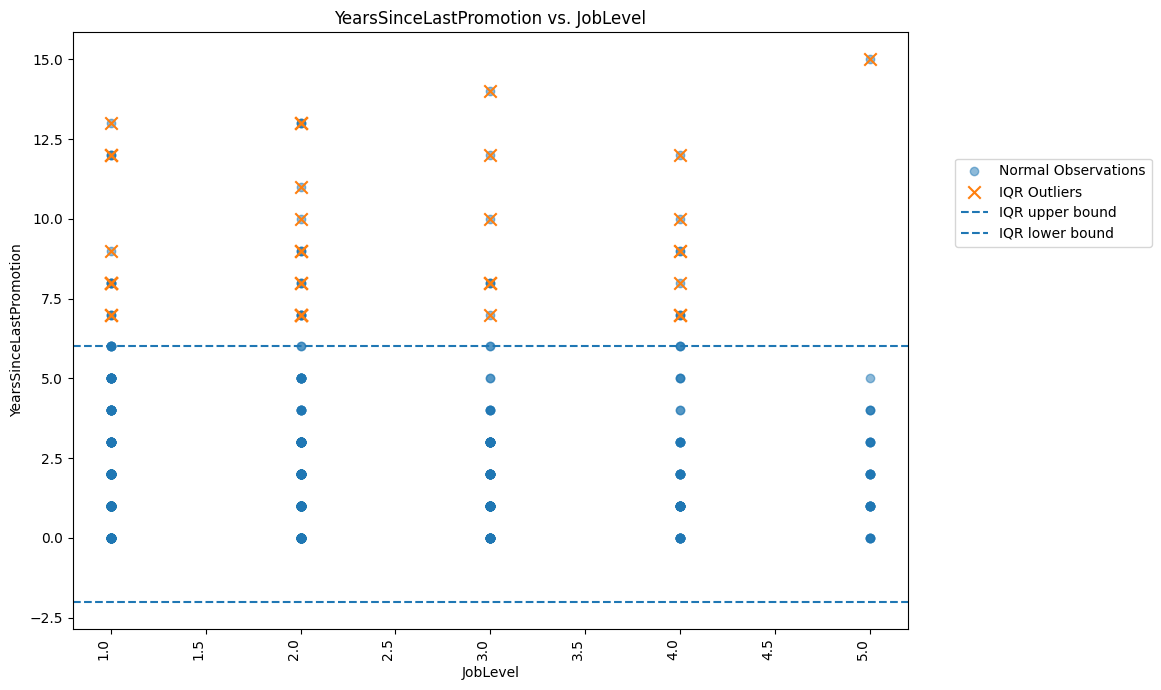

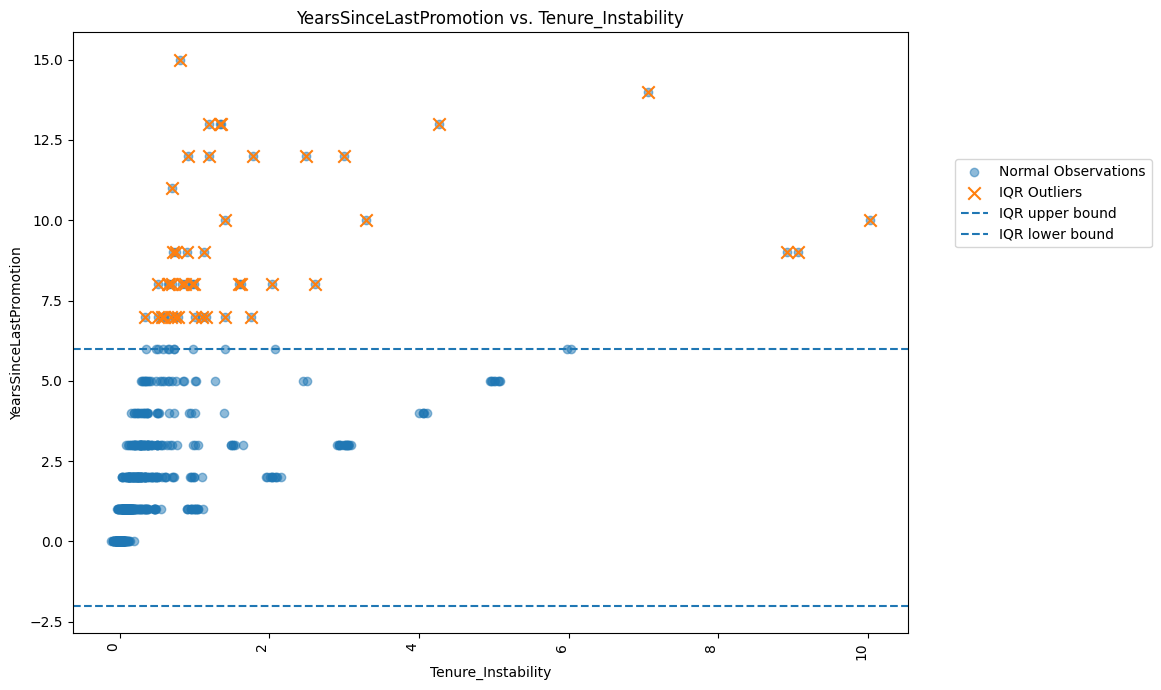

In [316]:
sus = 'YearsSinceLastPromotion'
checks = ['YearsAtCompany', 'JobLevel', 'Tenure_Instability']

for column in checks:
    scatters(train, column, sus)

L’analisi bivariata di `YearsSinceLastPromotion` permette di interpretare meglio i valori individuati come outlier dal metodo IQR.

Nel confronto con `YearsAtCompany`, i valori elevati di `YearsSinceLastPromotion` risultano in parte coerenti con dipendenti che hanno una permanenza aziendale più lunga. Tuttavia, sono presenti anche casi con molti anni dall’ultima promozione e una permanenza relativamente bassa in azienda. Questi casi non vengono considerati automaticamente errori, ma rappresentano profili da interpretare con attenzione, perché potrebbero indicare situazioni particolari di carriera o possibili incoerenze da verificare.

Il confronto con `JobLevel` mostra che gli outlier non sono concentrati in un solo livello lavorativo, ma compaiono su diversi livelli. Questo suggerisce che un alto numero di anni senza promozione non dipende esclusivamente dal livello gerarchico del dipendente. In alcuni casi può essere plausibile per profili già avanzati, mentre in altri può indicare una possibile stagnazione di carriera.

Infine, il confronto con `Tenure_Instability` mostra una relazione più evidente: molti valori elevati di `YearsSinceLastPromotion` sono associati anche a valori più alti di `Tenure_Instability`. Questo risultato è coerente con quanto osservato nella matrice di correlazione e suggerisce che la distanza dall’ultima promozione contribuisce alla lettura dell’instabilità del percorso aziendale.

Nel complesso, gli outlier di `YearsSinceLastPromotion` non vengono rimossi automaticamente. Essi possono rappresentare casi realistici di dipendenti con progressione di carriera lenta o stagnante, e potrebbero quindi contenere informazione utile per le successive analisi sul rischio di attrition.

rappresentazione grafica degli errori logici su `YearsSinceLastPromotion`e `YearsAtCompany`

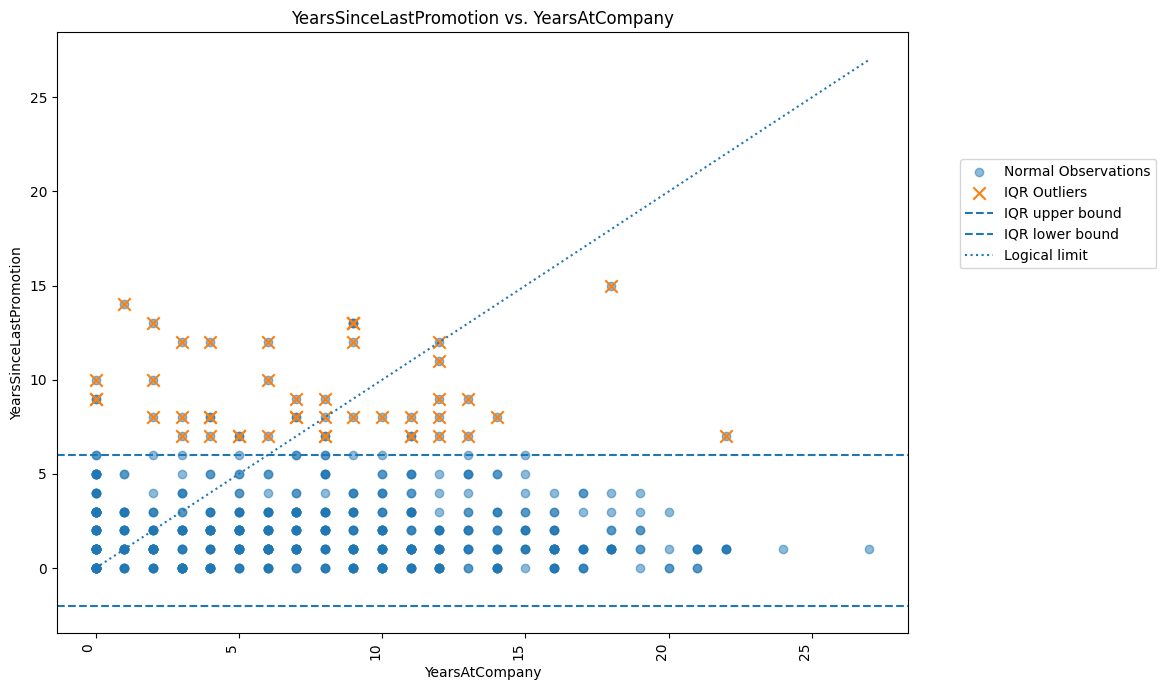

In [317]:
sus = 'YearsSinceLastPromotion'
test = 'YearsAtCompany'

mask, lower_bound, upper_bound = get_IQR_data(train.select_dtypes(include=np.number), sus)
plt.figure(figsize=(12,7))

plt.scatter(
    train['YearsAtCompany'],
    train[sus],
    alpha= 0.5,
    label= 'Normal Observations'
)

plt.scatter(
train.loc[mask, 'YearsAtCompany'],
train.loc[mask, sus],
marker="x",
s= 80,
label= 'IQR Outliers'
)

plt.axhline(upper_bound, linestyle="--", label="IQR upper bound")
plt.axhline(lower_bound, linestyle="--", label="IQR lower bound")

max_value = max(train['YearsAtCompany'].max(), train[sus].max())

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle=":",
    label="Logical limit"
)

plt.xticks(rotation=90, ha="right")

plt.title(f'{sus} vs. {test}')
plt.xlabel('YearsAtCompany')
plt.ylabel(sus)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 0.8))
plt.tight_layout()
plt.show()

**3)Tenure Instability**

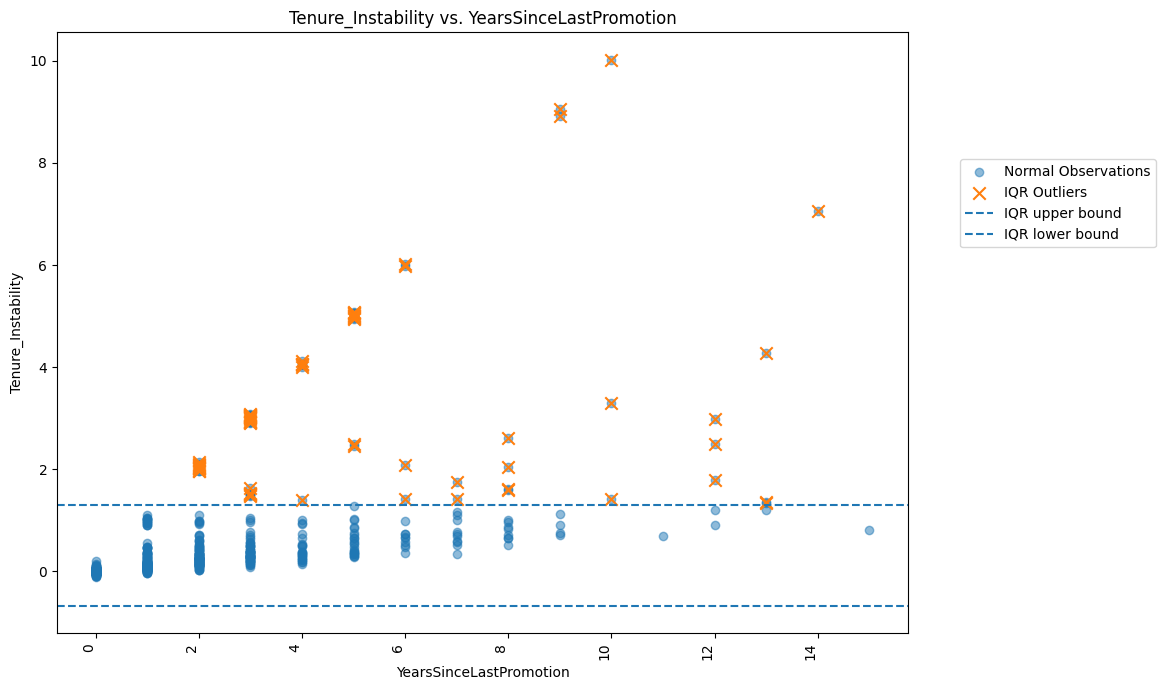

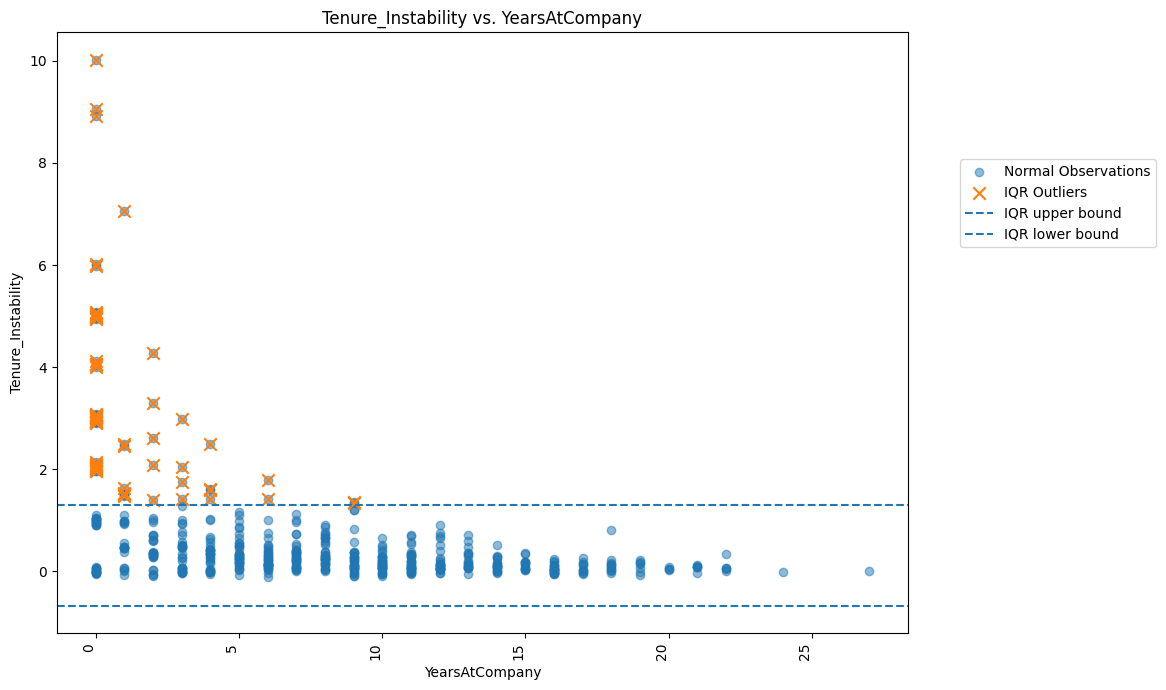

In [318]:
sus = 'Tenure_Instability'
check = ['YearsSinceLastPromotion', 'YearsAtCompany']

for column in check:
    scatters(train, column, sus)

L’analisi bivariata di `Tenure_Instability` conferma quanto emerso dalla matrice di correlazione. Nel confronto con `YearsSinceLastPromotion`, i valori più elevati di `Tenure_Instability` tendono a comparire quando aumenta il tempo trascorso dall’ultima promozione. Questo suggerisce che la variabile sia sensibile a situazioni di possibile stagnazione di carriera.

Nel confronto con `YearsAtCompany`, invece, gli outlier di `Tenure_Instability` sono concentrati soprattutto su valori bassi di permanenza in azienda. Questo indica che livelli elevati di instabilità possono essere associati a dipendenti con una tenure ridotta, oppure a profili in cui la permanenza, il ruolo e la progressione di carriera risultano meno stabili.

Nel complesso, i valori estremi di `Tenure_Instability` non vengono considerati errori da rimuovere automaticamente. Al contrario, sembrano rappresentare casi particolari ma interpretabili nel contesto HR, potenzialmente utili per descrivere profili con maggiore instabilità del percorso aziendale.

#### DISTANZA DI MAHALANOBIS
import librerie:

In [319]:
from scipy.stats import chi2

prova

In [320]:
def mahalanobis_distance(df, vc1, vc2, alpha= 0.975):
    data = df[[vc1, vc2]].copy()
    x_vector = data.to_numpy()
    medie = data.mean().to_numpy()
    S = np.cov(x_vector, rowvar=False)
    inverse_S = np.linalg.pinv(S)

    differenze = x_vector - medie

    mahalanobis_squared = []
    for differenza in differenze:
        differenza_colonna = differenza.reshape(-1, 1)
        distance_squared = (differenza_colonna.T @ inverse_S @ differenza_colonna)[0, 0]
        mahalanobis_squared.append(distance_squared)

    threshold = chi2.ppf(alpha, df=2)

    data["Mahalanobis_squared"] = mahalanobis_squared
    data["Mahalanobis_Outlier"] = data["Mahalanobis_squared"] > threshold

    n_outliers = data["Mahalanobis_Outlier"].sum()
    outlier_percentage = round(n_outliers / len(data) * 100, 2)
    
    return data, threshold, n_outliers, outlier_percentage


def mahalanobis_summary(df, alpha=0.975):

    summary = []
    variables = df.columns.tolist()

    for i in range(len(variables)):
        for j in range(i+1, len(variables)):
            
            result, threshold, n_outliers, outlier_percentage = mahalanobis_distance(df, variables[i], variables[j], alpha)

            summary.append({
                'Variable 1': variables[i],
                'Variable 2': variables[j],
                'Distanza di Mahalanobis': result,
                'Numero di outlier': n_outliers,
                'percentuale di outliers (%)': outlier_percentage
            })

    return pd.DataFrame(summary).sort_values(by='percentuale di outliers (%)', ascending=False)


In [321]:
mahalanobis_summary = mahalanobis_summary(continuous_variables)
print(mahalanobis_summary.head(20))

                  Variable 1               Variable 2  \
40             MonthlyIncome       Tenure_Instability   
103  YearsSinceLastPromotion       Tenure_Instability   
35             MonthlyIncome  YearsSinceLastPromotion   
117         Engagement_Score       Tenure_Instability   
104  YearsSinceLastPromotion      Random_Survey_Noise   
15          DistanceFromHome            MonthlyIncome   
119       Tenure_Instability      Random_Survey_Noise   
32             MonthlyIncome        TotalWorkingYears   
39             MonthlyIncome         Engagement_Score   
97        YearsInCurrentRole       Tenure_Instability   
108     YearsWithCurrManager       Tenure_Instability   
102  YearsSinceLastPromotion         Engagement_Score   
41             MonthlyIncome      Random_Survey_Noise   
92        YearsInCurrentRole  YearsSinceLastPromotion   
82         TotalWorkingYears       Tenure_Instability   
115    TrainingTimesLastYear       Tenure_Instability   
77         TotalWorkingYears  Y

In [322]:
def plot_top_mahalanobis_pairs(df, summary_df, top_n=12, alpha=0.975, n_cols=3):

    top_pairs = summary_df.head(top_n)

    n_rows = math.ceil(top_n / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows)
    )

    axes = axes.flatten()

    for plot_index, (_, row) in enumerate(top_pairs.iterrows()):

        vc1 = row["Variable 1"]
        vc2 = row["Variable 2"]

        data, threshold, n_outliers, outlier_percentage = mahalanobis_distance(
            df,
            vc1,
            vc2,
            alpha
        )

        normal_points = data["Mahalanobis_Outlier"] == False
        outlier_points = data["Mahalanobis_Outlier"] == True

        ax = axes[plot_index]

        ax.scatter(
            data.loc[normal_points, vc1],
            data.loc[normal_points, vc2],
            alpha=0.5,
            label="Normal"
        )

        ax.scatter(
            data.loc[outlier_points, vc1],
            data.loc[outlier_points, vc2],
            marker="x",
            s=60,
            label="Outlier"
        )

        ax.set_title(
            f"{vc2} vs {vc1}\nOutliers: {n_outliers} ({outlier_percentage}%)",
            fontsize=9
        )

        ax.set_xlabel(vc1, fontsize=8)
        ax.set_ylabel(vc2, fontsize=8)
        ax.tick_params(axis="both", labelsize=8)
        ax.grid(alpha=0.3)

    for j in range(len(top_pairs), len(axes)):
        axes[j].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

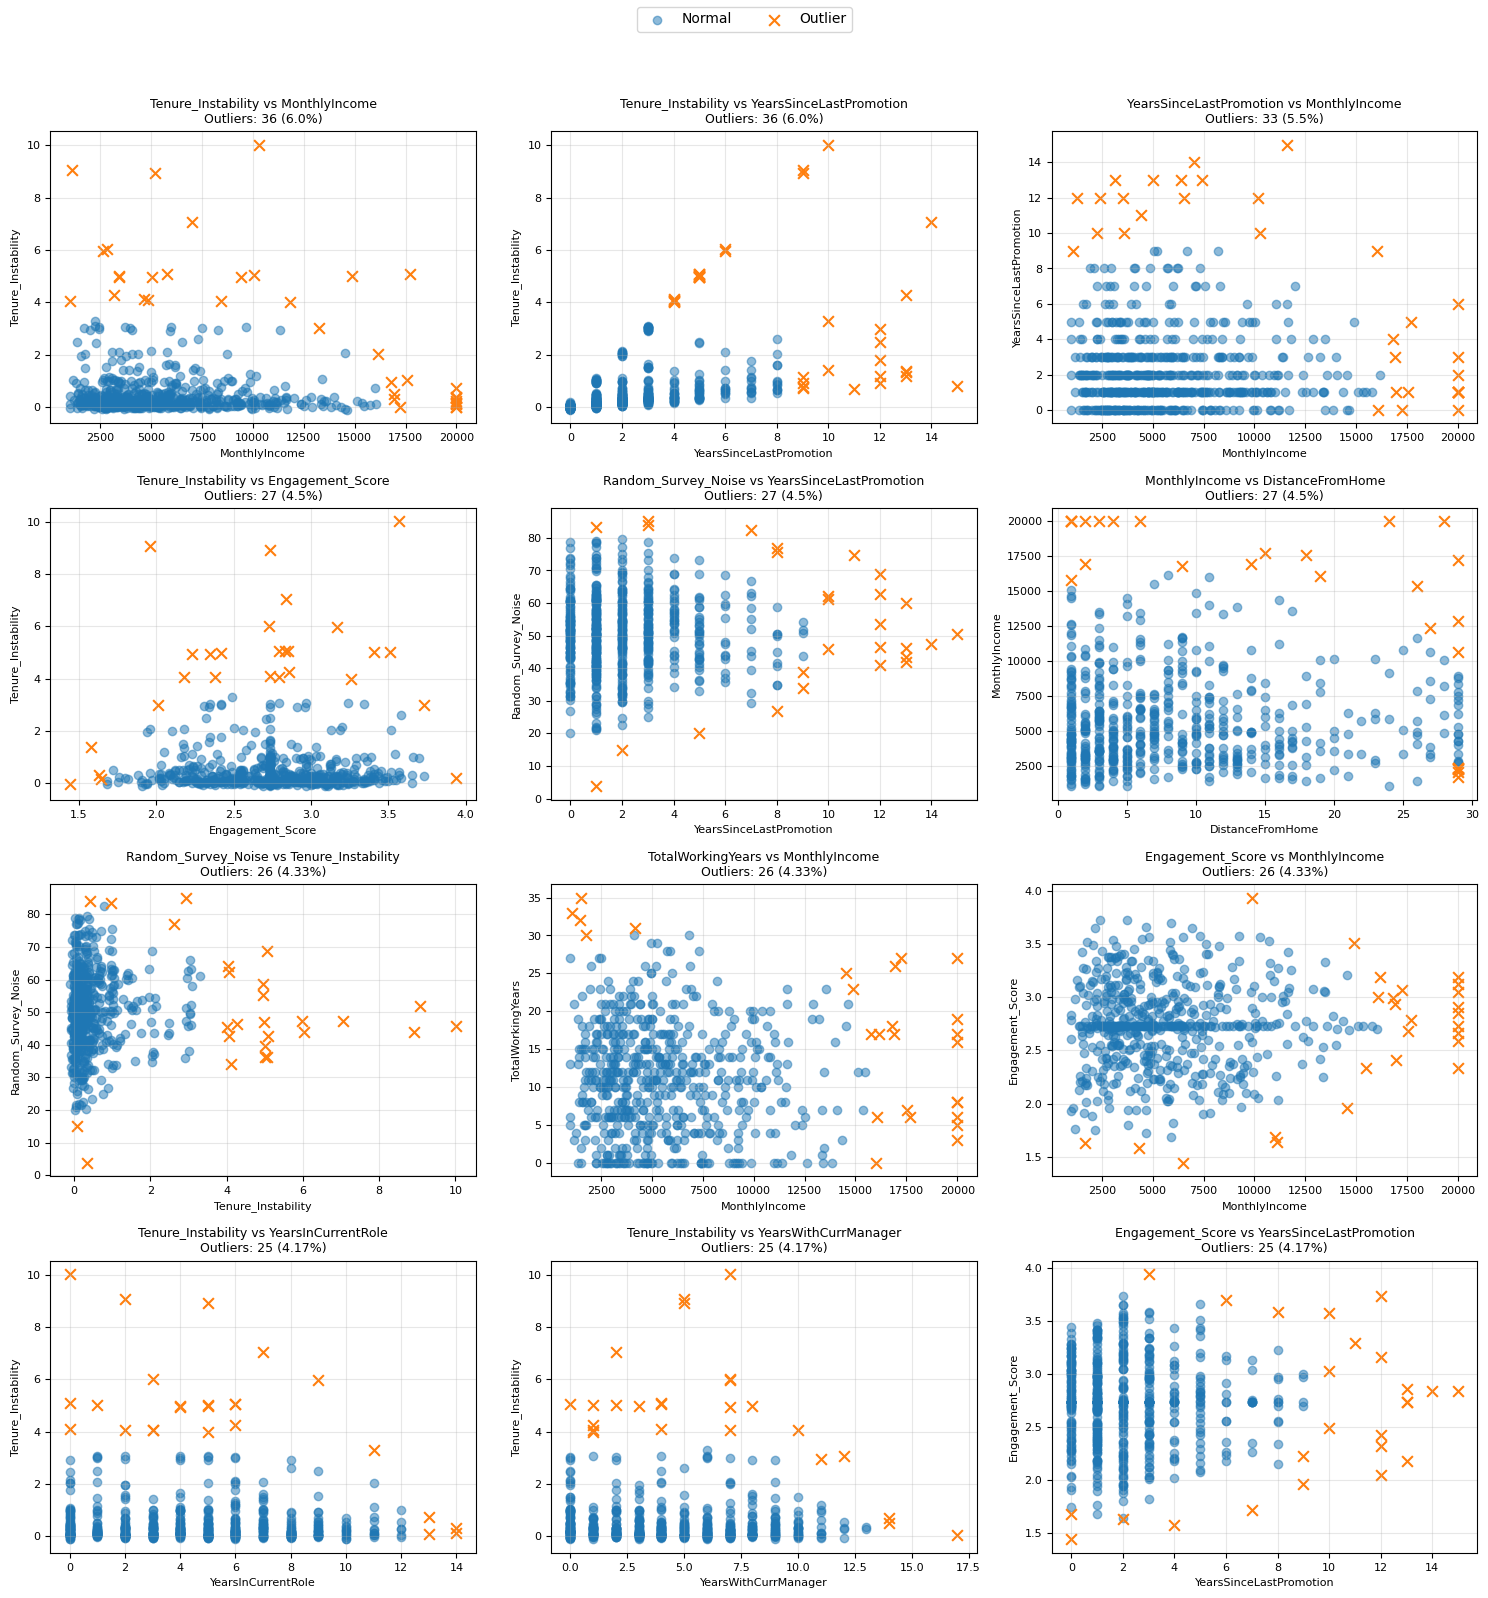

In [323]:
plot_top_mahalanobis_pairs(continuous_variables, mahalanobis_summary)

outliers:

In [354]:
bivariate_outlier = []
for df_coppia in mahalanobis_summary.head(15)["Distanza di Mahalanobis"]:
    bivariate_outlier.extend(df_coppia[df_coppia["Mahalanobis_Outlier"]].index)

train.loc[list(set(bivariate_outlier))]


,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Engagement_Score,Tenure_Instability,Random_Survey_Noise,Attrition
1,38,Male,Single,12,3,Other,Sales,Laboratory Technician,4,Travel_Rarely,...,12,5,7,0,1,3,1.72,0.519,32.29,0
2,40,Female,Married,14,4,Life Sciences,Sales,Research Scientist,2,Travel_Frequently,...,1,5,1,1,2,2,2.41,0.479,23.27,1
516,44,Male,Divorced,11,3,Medical,Research & Development,Sales Executive,2,Non-Travel,...,4,6,2,12,2,6,1.63,0.335,57.03,0
518,43,Female,Married,6,5,Marketing,Research & Development,Laboratory Technician,1,Non-Travel,...,9,0,3,3,4,5,3.19,0.378,45.72,0
16,40,Female,Divorced,3,3,Life Sciences,Research & Development,Human Resources,1,Non-Travel,...,6,2,2,0,4,3,3.05,0.334,53.43,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,53,Female,Single,23,3,Life Sciences,Research & Development,Research Scientist,4,Travel_Rarely,...,9,6,12,8,1,4,2.05,1.198,41.15,0
482,39,Male,Single,29,3,Life Sciences,Sales,Research Scientist,5,Non-Travel,...,10,5,3,2,5,3,3.15,0.288,54.71,1
488,38,Male,Divorced,19,2,Life Sciences,Research & Development,Sales Executive,2,Travel_Rarely,...,0,2,4,7,1,3,2.18,4.047,64.22,0
505,47,Male,Single,5,2,Medical,Research & Development,Research Scientist,5,Travel_Rarely,...,0,1,1,3,8,2,2.90,0.955,83.40,0


### 4.3.3 Analisi multivariata degli outlier tramite clustering

Dopo l’analisi univariata e bivariata, viene svolta un’analisi multivariata tramite clustering. L’obiettivo è individuare eventuali profili di dipendenti che risultano isolati o poco rappresentativi rispetto alla struttura generale del dataset.

A differenza della IQR, che analizza una variabile alla volta, il clustering considera più feature contemporaneamente. Questo permette di osservare se alcune osservazioni risultano anomale non per un singolo valore estremo, ma per una combinazione insolita di caratteristiche.

In questa fase il clustering viene utilizzato come strumento esplorativo e non supervisionato. La variabile target `Attrition` non viene utilizzata per costruire i cluster, perché l’obiettivo è analizzare la struttura interna dei dati senza influenzarla con l’informazione sul risultato finale.

#### K-Means
Import delle librerie

In [324]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD


#### Preparazione df per k-means clustering

In [325]:
clustering_features = [col for col in train if col not in ["Random_Survey_Noise", "Attrition"]]
df = train[clustering_features].copy()
df = df.select_dtypes(include= np.number)

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

#### Analisi del numero di cluster

In [326]:
cluster_number_values = range(2,10)

summary = []

for value in cluster_number_values:
    kmeans = KMeans(
        n_clusters= value,
        max_iter= 100,
        random_state= 42,
        n_init= 10,
    )

    labels = kmeans.fit_predict(df_scaled)

    summary.append({
        'cluster number': value,
        'intertia': kmeans.inertia_,
        'silhouette_score': silhouette_score(df_scaled, labels)
    })

print(f'analisi numero ottimale di cluster: \n {pd.DataFrame(summary)}')


analisi numero ottimale di cluster: 
    cluster number    intertia  silhouette_score
0               2  936.387579          0.135456
1               3  879.049824          0.076738
2               4  837.521815          0.070480
3               5  809.934596          0.064038
4               6  791.676589          0.061588
5               7  777.107039          0.059964
6               8  764.372369          0.058581
7               9  756.304281          0.052443


K-Means è stato utilizzato come analisi esplorativa, ma i valori bassi di silhouette indicano che i cluster non sono nettamente separati.
di conseguenza procediamo ad usare il numero di cluster con il valore di silhouette piu alto ovvero 2.

#### Scelta del numero di classi e inizializzazione del modello

In [327]:
cluster_number = 2
cluster_iterations = 100

kmeans = KMeans(
    n_clusters= cluster_number,
    max_iter= cluster_iterations,
    random_state= 42,
    n_init=10
)

labels = kmeans.fit_predict(df_scaled)

cluster_assignments = kmeans.labels_
centroids = kmeans.cluster_centers_
distances = kmeans.transform(df_scaled)


distance_to_assigned_centroid = distances[
    range(len(cluster_assignments)),
    cluster_assignments
]


save_info = train.copy()

save_info['KMeans_Cluster'] = labels
save_info['Distance_to_centroid'] = distance_to_assigned_centroid



possibili outliers:

In [328]:
threshold = save_info["Distance_to_centroid"].quantile(0.95)

save_info["KMeans_Multivariate_Outlier"] = (
    save_info["Distance_to_centroid"] > threshold
)

In [329]:
save_info[save_info["KMeans_Multivariate_Outlier"]][
    clustering_features + [
        "KMeans_Cluster",
        "Distance_to_centroid",
        "KMeans_Multivariate_Outlier"
    ]
].sort_values(by="Distance_to_centroid", ascending=False)

,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Engagement_Score,Tenure_Instability,KMeans_Cluster,Distance_to_centroid,KMeans_Multivariate_Outlier
113,24,Male,Single,3,2,Life Sciences,Research & Development,Sales Executive,1,Travel_Frequently,...,8,1,10,3,3,1.680000,-0.019,1,1.773458,True
31,35,Male,Single,3,4,Marketing,Research & Development,Sales Executive,2,Travel_Rarely,...,2,9,5,1,3,1.960000,9.066,1,1.723634,True
589,30,Male,Divorced,29,5,Medical,Research & Development,Manager,2,Travel_Rarely,...,5,1,1,1,0,2.250000,0.087,1,1.703825,True
505,47,Male,Single,5,2,Medical,Research & Development,Research Scientist,5,Travel_Rarely,...,1,1,3,8,2,2.900000,0.955,0,1.688875,True
473,37,Male,Married,9,4,Medical,Sales,Sales Executive,1,Non-Travel,...,4,12,6,9,6,3.730000,2.991,1,1.687098,True
576,32,Female,Married,3,3,Marketing,Sales,Sales Executive,5,Non-Travel,...,6,1,0,7,5,2.550000,0.099,0,1.682576,True
547,21,Male,Single,18,3,Medical,Research & Development,Healthcare Representative,4,Travel_Rarely,...,5,1,2,2,6,2.680000,1.013,1,1.653909,True
428,35,Female,Married,5,2,Marketing,Sales,Manufacturing Director,2,Travel_Rarely,...,5,9,5,7,0,2.734817,8.922,1,1.649312,True
70,21,Male,Married,6,1,Life Sciences,Sales,Manager,5,Travel_Rarely,...,0,15,0,3,2,2.840000,0.802,1,1.642051,True
431,22,Female,Married,18,2,Medical,Research & Development,Manufacturing Director,5,Non-Travel,...,5,2,11,7,0,3.290000,0.988,0,1.633204,True


rappresentazione grafica:

In [330]:
svd = TruncatedSVD(n_components=2, random_state=42)

df_2d = svd.fit_transform(df_scaled)

save_info["Component_1"] = df_2d[:, 0]
save_info["Component_2"] = df_2d[:, 1]

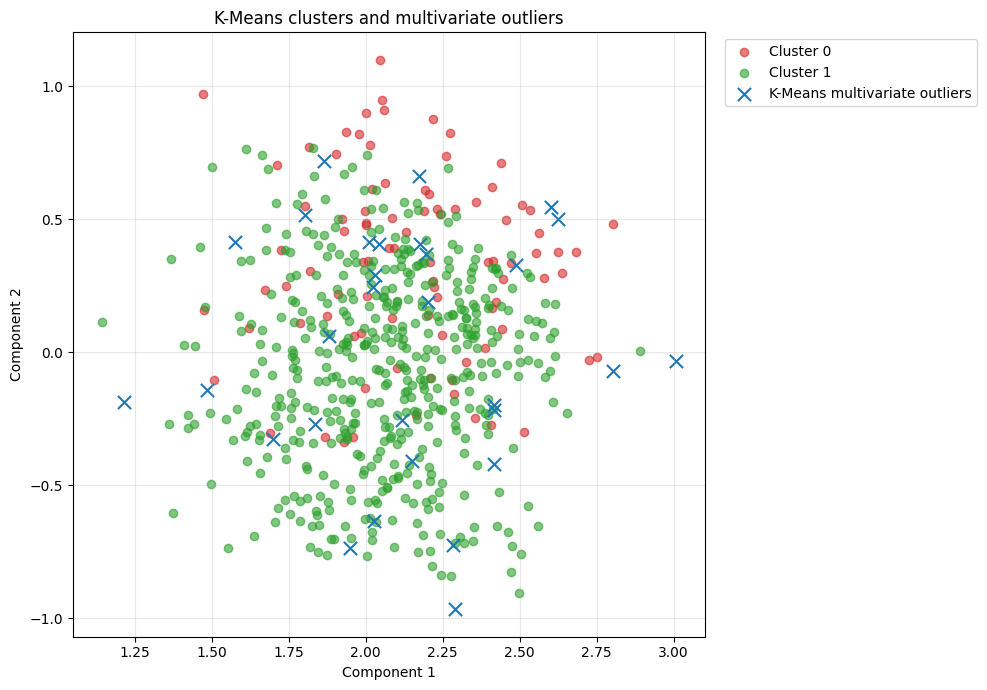

In [331]:
plt.figure(figsize=(10, 7))

outlier_points = save_info["KMeans_Multivariate_Outlier"] == True

clusters = sorted(save_info['KMeans_Cluster'].unique())

for i, cluster in enumerate(clusters):

    colors = ["tab:red", "tab:green", "tab:purple", "tab:orange", "tab:yellow"]

    mask = ((save_info["KMeans_Cluster"] == cluster) & (save_info["KMeans_Multivariate_Outlier"] == False))

    plt.scatter(
        save_info.loc[mask, "Component_1"],
        save_info.loc[mask, "Component_2"],
        color=colors[i],
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.scatter(
    save_info.loc[outlier_points, "Component_1"],
    save_info.loc[outlier_points, "Component_2"],
    marker="x",
    s=90,
    label="K-Means multivariate outliers"
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("K-Means clusters and multivariate outliers")
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

#### 4.3.3.2 Analisi multivariata tramite DBSCAN

Dopo l'applicazione di K-Means, viene utilizzato anche DBSCAN come secondo metodo di clustering per l'individuazione di potenziali outlier multivariati.

DBSCAN è un algoritmo density-based: invece di richiedere un numero di cluster fissato a priori, identifica regioni dense di osservazioni e considera come noise i punti che non appartengono a nessuna regione sufficientemente densa. Questi punti vengono quindi interpretati come potenziali outlier multivariati.

A differenza di K-Means, che individua outlier tramite la distanza dal centroide del cluster, DBSCAN segnala osservazioni isolate rispetto alla densità locale dei dati. Il confronto tra i due metodi permette quindi di valutare se alcuni profili risultano sospetti secondo criteri differenti.

Per il tuning degli iperparametri `eps` e `min_samples`, viene applicata una grid search sistematica con valutazione tramite silhouette score e numero di cluster. Il parametro `eps` viene stimato inizialmente con la k-distance knee heuristic, e successivamente perturbato per esplorare soluzioni migliori.

import delle librerie

In [332]:
from sklearn.cluster import DBSCAN

tuning di eps e min_sample per ottimizzazione di DBSCAN

In [333]:
import optuna
import gower
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# Usa lo STESSO set di feature del K-Means per confrontabilità
dbscan_features = [
    col for col in train.columns
    if col not in ["Attrition", "Random_Survey_Noise"]
]

df_dbscan = train[dbscan_features].copy()

# Calcola la matrice Gower (gestisce automaticamente mix numerico/categorico)
gower_matrix = gower.gower_matrix(df_dbscan)


def get_knee_eps(distance_matrix, min_samples):
    """Stima eps tramite knee detection sulla curva k-distance."""
    nbrs = NearestNeighbors(
        n_neighbors=min_samples,
        metric='precomputed'
    ).fit(distance_matrix)

    distances, _ = nbrs.kneighbors(distance_matrix)
    k_distances = np.sort(distances[:, -1])

    knee = KneeLocator(
        range(len(k_distances)),
        k_distances,
        curve='convex',
        direction='increasing'
    )
    if knee.knee is None:
        return None

    return k_distances[knee.knee]


def objective(trial):

    min_samples = trial.suggest_int("min_samples", 3, 30)

    # Stima eps dal knee, poi lascia Optuna esplorare attorno a quel valore
    knee_eps = get_knee_eps(gower_matrix, min_samples)

    if knee_eps is None or knee_eps <= 0:
        trial.set_user_attr("eps", None)
        trial.set_user_attr("n_clusters", 0)
        trial.set_user_attr("n_noise", None)
        trial.set_user_attr("noise_ratio", None)
        trial.set_user_attr("silhouette", None)
        trial.set_user_attr("reject_reason", "no_knee")
        return float("-inf")

    # eps come vero iperparametro: Optuna esplora da 50% a 150% del knee
    eps = trial.suggest_float("eps", knee_eps * 0.5, knee_eps * 1.5)

    trial.set_user_attr("knee_eps", round(float(knee_eps), 4))

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="precomputed"
    )

    labels = dbscan.fit_predict(gower_matrix)

    unique_labels = set(labels)
    n_clusters = len(unique_labels - {-1})
    n_noise = int(np.sum(labels == -1))
    noise_ratio = n_noise / len(labels)

    trial.set_user_attr("eps", round(float(eps), 4))
    trial.set_user_attr("n_clusters", int(n_clusters))
    trial.set_user_attr("n_noise", n_noise)
    trial.set_user_attr("noise_ratio", round(float(noise_ratio), 4))

    # --- Filtri di base ---
    if n_clusters < 1:
        trial.set_user_attr("silhouette", None)
        trial.set_user_attr("reject_reason", "no_cluster")
        return float("-inf")

    if noise_ratio == 0:
        trial.set_user_attr("silhouette", None)
        trial.set_user_attr("reject_reason", "no_noise")
        return float("-inf")

    if noise_ratio > 0.50:
        trial.set_user_attr("silhouette", None)
        trial.set_user_attr("reject_reason", "too_much_noise")
        return float("-inf")

    # --- Calcolo silhouette (solo su punti non-noise) ---
    non_noise_mask = labels != -1
    n_non_noise = non_noise_mask.sum()

    if n_clusters >= 2 and n_non_noise > n_clusters:
        sil = silhouette_score(
            gower_matrix[non_noise_mask][:, non_noise_mask],
            labels[non_noise_mask],
            metric='precomputed'
        )
    else:
        # Con 1 cluster la silhouette non è definita: usiamo 0
        sil = 0.0

    trial.set_user_attr("silhouette", round(float(sil), 4))
    trial.set_user_attr("reject_reason", "valid")

    # --- Score composito ---
    # Componente 1: qualità del clustering (silhouette, range [-1, 1])
    # Componente 2: penalità se noise troppo alto o troppo basso
    noise_penalty = -abs(np.log10(noise_ratio / 0.05)) if noise_ratio > 0 else -10

    score = 0.6 * sil + 0.4 * max(noise_penalty, -2)

    return score

lanciamo lo studio:

In [334]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

[I 2026-05-23 11:11:19,340] A new study created in memory with name: no-name-e89c08eb-6297-48a1-9616-a0019d4b835b
[I 2026-05-23 11:11:19,354] Trial 0 finished with value: -inf and parameters: {'min_samples': 9, 'eps': 0.19670228369394724}. Best is trial 0 with value: -inf.
[I 2026-05-23 11:11:19,362] Trial 1 finished with value: -0.4 and parameters: {'min_samples': 25, 'eps': 0.2662466858546994}. Best is trial 1 with value: -0.4.
[I 2026-05-23 11:11:19,374] Trial 2 finished with value: -0.590848501887865 and parameters: {'min_samples': 6, 'eps': 0.25784546233000427}. Best is trial 1 with value: -0.4.
[I 2026-05-23 11:11:19,385] Trial 3 finished with value: -inf and parameters: {'min_samples': 24, 'eps': 0.40931368128416873}. Best is trial 1 with value: -0.4.
[I 2026-05-23 11:11:19,393] Trial 4 finished with value: -0.005889302728282558 and parameters: {'min_samples': 12, 'eps': 0.23910803598461247}. Best is trial 4 with value: -0.005889302728282558.
[I 2026-05-23 11:11:19,404] Trial 5 

plot dei grafici per lo studio dell'ottimizzazione:

['number', 'value', 'datetime_start', 'datetime_complete', 'duration', 'params_eps', 'params_min_samples', 'user_attrs_eps', 'user_attrs_knee_eps', 'user_attrs_n_clusters', 'user_attrs_n_noise', 'user_attrs_noise_ratio', 'user_attrs_reject_reason', 'user_attrs_silhouette', 'state']


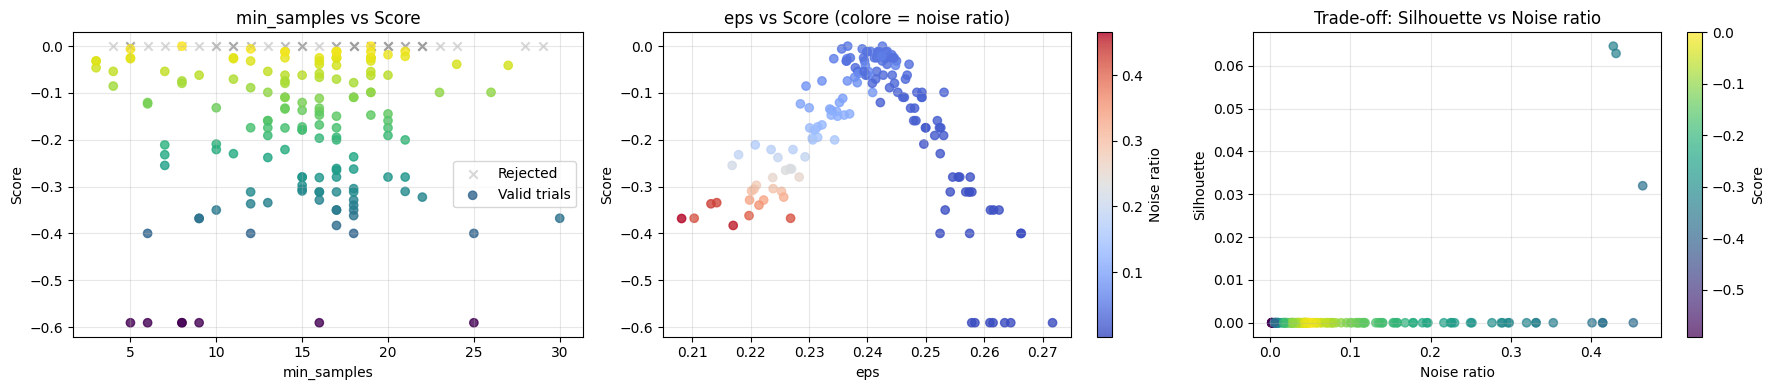

In [335]:
trials_df = study.trials_dataframe()

print(trials_df.columns.tolist())

plot_trials = trials_df[
    trials_df["user_attrs_eps"].notna()
].copy()

valid_trials = plot_trials[
    plot_trials["value"] > float("-inf")
].copy()

# Filtra via i -inf
valid_trials = valid_trials[np.isfinite(valid_trials["value"])].copy()

invalid_trials = plot_trials[
    ~np.isfinite(plot_trials["value"])
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: min_samples vs score
axes[0].scatter(
    invalid_trials["params_min_samples"],
    [0] * len(invalid_trials),
    alpha=0.3,
    label="Rejected", marker="x", color="gray"
)
if len(valid_trials) > 0:
    axes[0].scatter(
        valid_trials["params_min_samples"],
        valid_trials["value"],
        alpha=0.8,
        c=valid_trials["value"], cmap="viridis",
        label="Valid trials"
    )
axes[0].set_xlabel("min_samples")
axes[0].set_ylabel("Score")
axes[0].set_title("min_samples vs Score")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: eps vs score
if len(valid_trials) > 0:
    axes[1].scatter(
        valid_trials["params_eps"],
        valid_trials["value"],
        alpha=0.8,
        c=valid_trials["user_attrs_noise_ratio"], cmap="coolwarm",
        label="Valid trials"
    )
    plt.colorbar(
        axes[1].collections[-1], ax=axes[1], label="Noise ratio"
    )
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Score")
axes[1].set_title("eps vs Score (colore = noise ratio)")
axes[1].grid(alpha=0.3)

# Plot 3: silhouette vs noise_ratio
if len(valid_trials) > 0:
    axes[2].scatter(
        valid_trials["user_attrs_noise_ratio"],
        valid_trials["user_attrs_silhouette"],
        alpha=0.7,
        c=valid_trials["value"], cmap="viridis"
    )
    plt.colorbar(
        axes[2].collections[-1], ax=axes[2], label="Score"
    )
axes[2].set_xlabel("Noise ratio")
axes[2].set_ylabel("Silhouette")
axes[2].set_title("Trade-off: Silhouette vs Noise ratio")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

relazione eps, min sample e score:

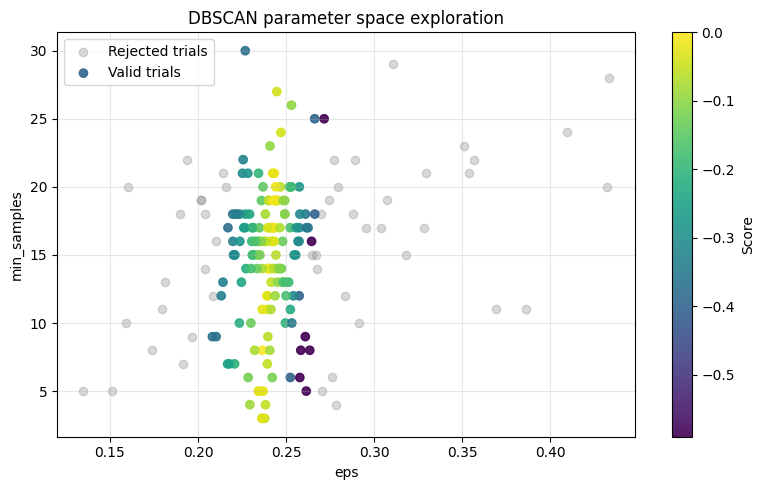

In [336]:
plt.figure(figsize=(8, 5))

if len(invalid_trials) > 0:
    plt.scatter(
        invalid_trials["user_attrs_eps"],
        invalid_trials["params_min_samples"],
        alpha=0.3, color="gray",
        label="Rejected trials"
    )

if len(valid_trials) > 0:
    scatter = plt.scatter(
        valid_trials["params_eps"],
        valid_trials["params_min_samples"],
        c=valid_trials["value"],
        cmap="viridis",
        alpha=0.9,
        label="Valid trials"
    )
    plt.colorbar(scatter, label="Score")

plt.xlabel("eps")
plt.ylabel("min_samples")
plt.title("DBSCAN parameter space exploration")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

results:


In [337]:
trials_df = study.trials_dataframe()

diagnostic_table = trials_df[
    [
        "number",
        "value",
        "params_min_samples",
        "params_eps",
        "user_attrs_n_clusters",
        "user_attrs_n_noise",
        "user_attrs_noise_ratio",
        "user_attrs_silhouette",
        "user_attrs_reject_reason"
    ]
].sort_values(
    by="value",
    ascending=False
)

print("Top 20 trial:")
print(diagnostic_table.head(20).to_string())

print("\nRejection reasons:")
print(diagnostic_table["user_attrs_reject_reason"].value_counts())

Top 20 trial:
     number     value  params_min_samples  params_eps  user_attrs_n_clusters  user_attrs_n_noise  user_attrs_noise_ratio  user_attrs_silhouette user_attrs_reject_reason
191     191  0.000000                  19    0.242567                      1                  30                  0.0500                    0.0                    valid
32       32  0.000000                   8    0.236619                      1                  30                  0.0500                    0.0                    valid
4         4 -0.005889                  12    0.239108                      1                  29                  0.0483                    0.0                    valid
38       38 -0.005889                   5    0.235600                      1                  29                  0.0483                    0.0                    valid
161     161 -0.011211                  21    0.243400                      1                  32                  0.0533                    0

quindi la scelta ottimizzata dei valori per il nostro DBSCAN sarà:

In [338]:
best_trial = study.best_trial

best_min_samples = best_trial.params["min_samples"]
best_eps = best_trial.params["eps"]

print("Best DBSCAN configuration")
print(f"eps: {round(best_eps, 4)}")
print(f"min_samples: {best_min_samples}")
print(f"score: {round(best_trial.value, 4)}")
print(f"n_clusters: {best_trial.user_attrs['n_clusters']}")
print(f"n_noise: {best_trial.user_attrs['n_noise']}")
print(f"noise_ratio: {best_trial.user_attrs['noise_ratio']}")
print(f"silhouette: {best_trial.user_attrs['silhouette']}")
print(f"knee_eps: {best_trial.user_attrs.get('knee_eps', 'N/A')}")

Best DBSCAN configuration
eps: 0.2366
min_samples: 8
score: 0.0
n_clusters: 1
n_noise: 30
noise_ratio: 0.05
silhouette: 0.0
knee_eps: 0.2671


applicazione del dbscan sul nostro dataset di train:

In [339]:
dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric="precomputed"
)

dbscan_labels = dbscan_final.fit_predict(gower_matrix)

save_info["DBSCAN_Cluster"] = dbscan_labels
save_info["DBSCAN_Multivariate_Outlier"] = save_info["DBSCAN_Cluster"] == -1

risultati del DBSCAN:

In [340]:
print("DBSCAN cluster distribution:\n")
print(save_info["DBSCAN_Cluster"].value_counts().sort_index())

print("\nNumber of DBSCAN multivariate outliers:")
print(save_info["DBSCAN_Multivariate_Outlier"].sum())

print("\nPercentage of DBSCAN multivariate outliers:")
print(round(save_info["DBSCAN_Multivariate_Outlier"].mean() * 100, 2))

DBSCAN cluster distribution:

DBSCAN_Cluster
-1     30
 0    570
Name: count, dtype: int64

Number of DBSCAN multivariate outliers:
30

Percentage of DBSCAN multivariate outliers:
5.0


ricalcolo le componenti per il plot

In [ ]:
svd_db = TruncatedSVD(
    n_components= 2,
    random_state= 42
)
gower_2d_svd = svd_db.fit_transform(gower_matrix)

save_info["DBSCAN_comp_1_svd"] = gower_2d_svd[:,0]
save_info["DBSCAN_comp_2_svd"] = gower_2d_svd[:,1]


plot DBSCAN:

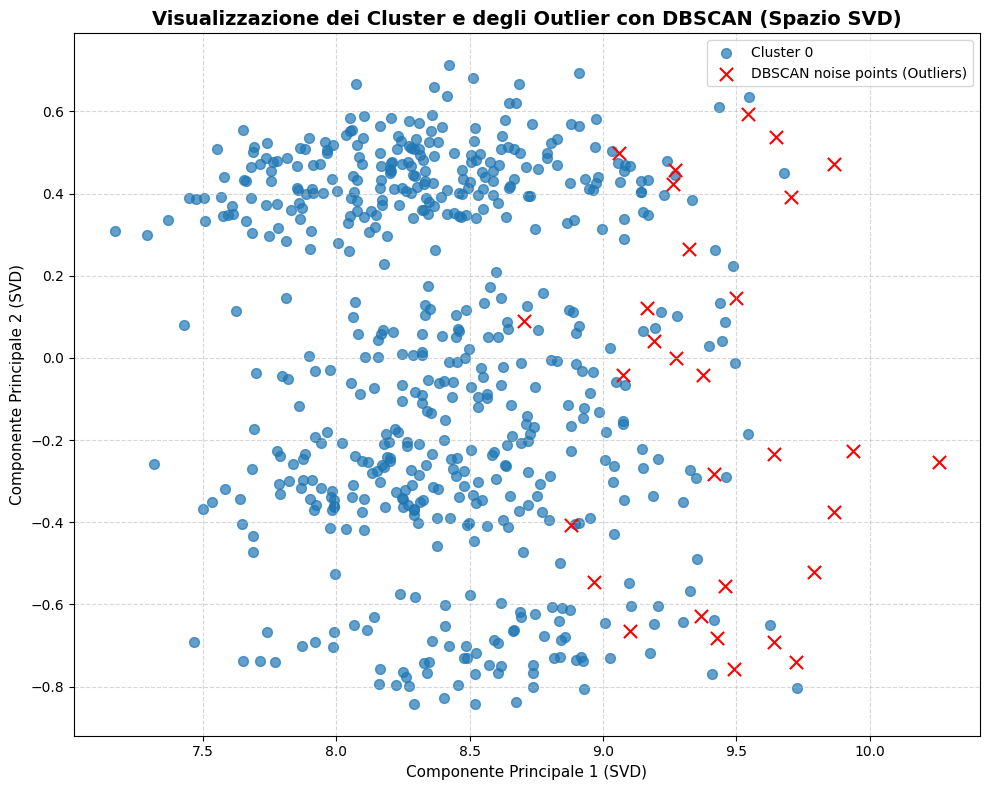

In [ ]:
comp_svd_x = "DBSCAN_comp_1_svd" 
comp_svd_y = "DBSCAN_comp_2_svd" 

dbscan_outliers = save_info["DBSCAN_Multivariate_Outlier"] == True
dbscan_normal = save_info["DBSCAN_Multivariate_Outlier"] == False
clusters = sorted(save_info.loc[dbscan_normal, "DBSCAN_Cluster"].unique())

plt.figure(figsize=(10, 8))

for cluster in clusters:
    mask = (
        (save_info["DBSCAN_Cluster"] == cluster) &
        (save_info["DBSCAN_Multivariate_Outlier"] == False)
    )
    plt.scatter(
        save_info.loc[mask, comp_svd_x],
        save_info.loc[mask, comp_svd_y],
        label=f"Cluster {cluster}",
        alpha=0.7,  
        s=50        
    )

plt.scatter(
    save_info.loc[dbscan_outliers, comp_svd_x],
    save_info.loc[dbscan_outliers, comp_svd_y],
    color="red",
    marker="x",
    s=90,  
    label="DBSCAN noise points (Outliers)"
)

plt.title("Visualizzazione dei Cluster e degli Outlier con DBSCAN (Spazio SVD)", fontsize=14, fontweight="bold")
plt.xlabel("Componente Principale 1 (SVD)", fontsize=11)
plt.ylabel("Componente Principale 2 (SVD)", fontsize=11)
plt.legend(loc="best", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


outliers segnalati da DBSCAN

In [352]:
dbscan_outliers_df = save_info[save_info["DBSCAN_Multivariate_Outlier"]==True]
dbscan_outliers_df

,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,KMeans_Multivariate_Outlier,Component_1,Component_2,DBSCAN_Cluster,DBSCAN_Multivariate_Outlier,DBSCAN_comp_1_svd,DBSCAN_comp_2_svd,IsoForest_Outlier,IsoForest_Anomaly_Score,outlier_votes
41,37,Male,Married,23,5,Technical Degree,Human Resources,Sales Executive,2,Travel_Rarely,...,False,2.561448,0.449750,-1,True,9.270089,0.456849,False,0.001235,1
42,25,Male,Divorced,5,5,Life Sciences,Research & Development,Sales Representative,3,Travel_Frequently,...,False,2.230283,-0.336136,-1,True,9.321174,0.264101,True,-0.008595,2
77,32,Female,Married,15,3,Life Sciences,Human Resources,Laboratory Technician,2,Travel_Frequently,...,False,1.764945,-0.327801,-1,True,8.878564,-0.406414,False,0.030078,1
92,46,Male,Married,5,1,Life Sciences,Sales,Sales Representative,2,Travel_Frequently,...,True,2.117409,-0.255828,-1,True,9.704234,0.391433,True,-0.009438,3
105,41,Female,Single,20,3,Medical,Sales,Sales Representative,1,Non-Travel,...,False,1.929249,-0.337718,-1,True,9.790161,-0.522021,False,0.000183,1
113,24,Male,Single,3,2,Life Sciences,Research & Development,Sales Executive,1,Travel_Frequently,...,True,1.215131,-0.187524,-1,True,9.866128,0.473162,True,-0.035964,3
172,25,Male,Single,10,5,Life Sciences,Sales,Sales Executive,4,Travel_Rarely,...,False,2.231966,0.207211,-1,True,9.649386,0.536812,True,-0.049936,2
200,35,Male,Single,11,3,Medical,Research & Development,Research Director,5,Travel_Frequently,...,False,2.326931,-0.036546,-1,True,9.498923,0.146335,False,0.024204,1
237,27,Male,Married,25,3,Technical Degree,Human Resources,Manager,1,Travel_Rarely,...,False,1.677685,0.465948,-1,True,9.075829,-0.042142,False,0.048352,1
264,38,Female,Married,2,1,Technical Degree,Sales,Manufacturing Director,5,Travel_Rarely,...,False,1.611163,0.762984,-1,True,9.101052,-0.665332,False,0.044704,1


confronto DBSCAN vs K-MEANS

In [343]:
comparison = pd.crosstab(
    save_info["KMeans_Multivariate_Outlier"],
    save_info["DBSCAN_Multivariate_Outlier"],
    rownames=["KMeans Outlier"],
    colnames=["DBSCAN Outlier"]
)

comparison


common_outliers = save_info[
    (save_info["KMeans_Multivariate_Outlier"] == True) &
    (save_info["DBSCAN_Multivariate_Outlier"] == True)
]

common_outliers[
    [
        "KMeans_Cluster",
        "Distance_to_centroid",
        "KMeans_Multivariate_Outlier",
        "DBSCAN_Cluster",
        "DBSCAN_Multivariate_Outlier"
    ]
].sort_values(
    by="Distance_to_centroid",
    ascending=False
)

,KMeans_Cluster,Distance_to_centroid,KMeans_Multivariate_Outlier,DBSCAN_Cluster,DBSCAN_Multivariate_Outlier
113,1,1.773458,True,-1,True
505,0,1.688875,True,-1,True
576,0,1.682576,True,-1,True
431,0,1.633204,True,-1,True
92,1,1.583006,True,-1,True
321,1,1.577201,True,-1,True
371,1,1.542066,True,-1,True


### 4.3.3.3 Limiti dei metodi density-based e introduzione di Isolation Forest

Il confronto tra K-Means e DBSCAN evidenzia un risultato comune: il dataset non presenta una struttura di cluster netta.

- **K-Means** raggiunge una silhouette massima di 0.13, indicando cluster debolmente separati.
- **DBSCAN** identifica un unico cluster, trattando come noise solo i punti ai margini estremi dello spazio Gower.

La causa è strutturale: i dati HR descrivono profili continui senza confini naturali tra gruppi. Con ~30 feature miste (numeriche, ordinali, categoriche), la distanza Gower diventa poco discriminante — effetto noto come *curse of dimensionality* per i metodi density-based.

Per superare questo limite si adotta **Isolation Forest**, un algoritmo progettato specificamente per l'anomaly detection. A differenza dei metodi basati su distanza o densità, Isolation Forest individua outlier tramite il principio di **isolamento**: i punti anomali, avendo valori insoliti, vengono isolati con poche partizioni casuali, mentre i punti normali richiedono molte più suddivisioni. Questo approccio è robusto in alta dimensionalità e non richiede la definizione di cluster.

In [344]:
from sklearn.ensemble import IsolationForest

# Stesse feature numeriche del K-Means per confrontabilità
iso_features = [col for col in train.columns if col not in ["Attrition", "Random_Survey_Noise"]]
df_iso = train[iso_features].copy()
df_iso = df_iso.select_dtypes(include=np.number)

scaler_iso = MinMaxScaler()
df_iso_scaled = scaler_iso.fit_transform(df_iso)

#### Tuning della contamination tramite grid search

Il parametro `contamination` controlla la proporzione attesa di outlier. Viene valutato sistematicamente per confrontare il numero di anomalie individuate e la coerenza con gli altri metodi.

In [345]:
contamination_values = [0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15]

iso_results = []

for cont in contamination_values:
    iso_model = IsolationForest(
        contamination=cont,
        n_estimators=300,
        max_samples='auto',
        random_state=42
    )

    iso_labels = iso_model.fit_predict(df_iso_scaled)
    iso_scores = iso_model.decision_function(df_iso_scaled)

    n_outliers = (iso_labels == -1).sum()

    iso_results.append({
        'contamination': cont,
        'n_outliers': n_outliers,
        'outlier_pct': round(n_outliers / len(iso_labels) * 100, 2),
        'mean_score_outliers': round(iso_scores[iso_labels == -1].mean(), 4),
        'mean_score_normal': round(iso_scores[iso_labels == 1].mean(), 4),
    })

iso_results_df = pd.DataFrame(iso_results)
print(iso_results_df.to_string(index=False))

 contamination  n_outliers  outlier_pct  mean_score_outliers  mean_score_normal
          0.01           6          1.0              -0.0117             0.0779
          0.02          12          2.0              -0.0119             0.0712
          0.03          18          3.0              -0.0171             0.0606
          0.05          30          5.0              -0.0161             0.0542
          0.07          42          7.0              -0.0185             0.0477
          0.10          60         10.0              -0.0174             0.0440
          0.15          90         15.0              -0.0187             0.0376


#### Selezione della contamination e applicazione del modello

In [346]:
# Contamination al 5% — coerente con la soglia usata nel K-Means (95° percentile)
best_contamination = 0.05

iso_final = IsolationForest(
    contamination=best_contamination,
    n_estimators=300,
    max_samples='auto',
    random_state=42
)

iso_predictions = iso_final.fit_predict(df_iso_scaled)
iso_scores = iso_final.decision_function(df_iso_scaled)

save_info["IsoForest_Outlier"] = iso_predictions == -1
save_info["IsoForest_Anomaly_Score"] = iso_scores

print(f"Isolation Forest outlier: {save_info['IsoForest_Outlier'].sum()}")
print(f"Percentuale: {round(save_info['IsoForest_Outlier'].mean() * 100, 2)}%")

Isolation Forest outlier: 30
Percentuale: 5.0%


#### Distribuzione degli anomaly score

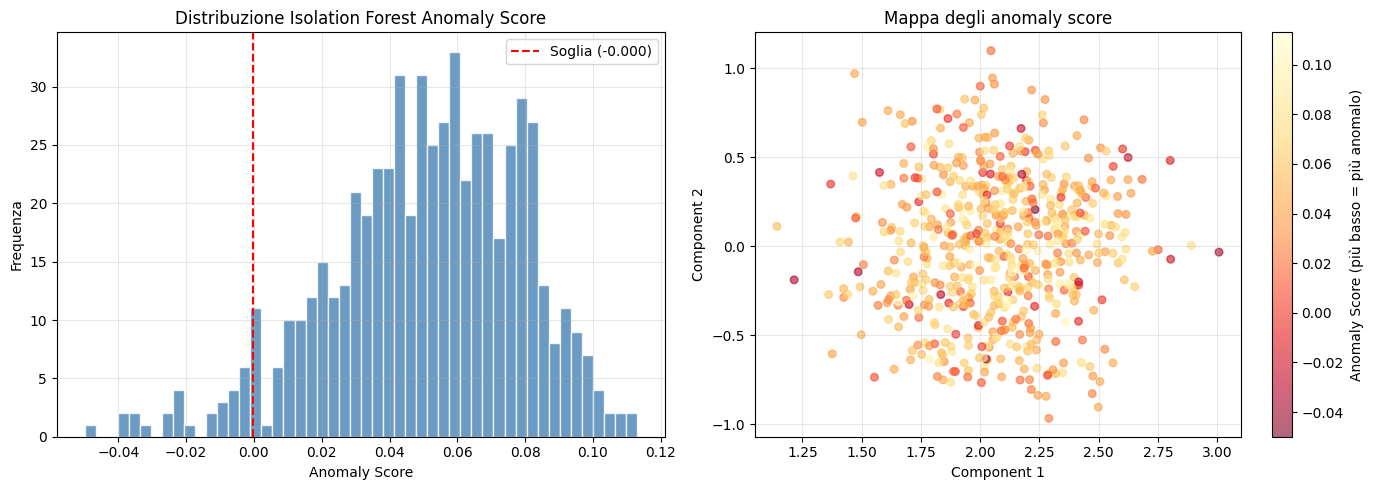

In [347]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Istogramma anomaly score
axes[0].hist(
    save_info["IsoForest_Anomaly_Score"],
    bins=50,
    color="steelblue",
    edgecolor="white",
    alpha=0.8
)

threshold = iso_scores[iso_predictions == -1].max()
axes[0].axvline(threshold, color="red", linestyle="--",
                label=f"Soglia ({threshold:.3f})")
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Frequenza")
axes[0].set_title("Distribuzione Isolation Forest Anomaly Score")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter con anomaly score come colore
scatter = axes[1].scatter(
    save_info["Component_1"],
    save_info["Component_2"],
    c=save_info["IsoForest_Anomaly_Score"],
    cmap="YlOrRd_r",
    alpha=0.6,
    s=30
)
plt.colorbar(scatter, ax=axes[1], label="Anomaly Score (più basso = più anomalo)")
axes[1].set_xlabel("Component 1")
axes[1].set_ylabel("Component 2")
axes[1].set_title("Mappa degli anomaly score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Visualizzazione degli outlier Isolation Forest

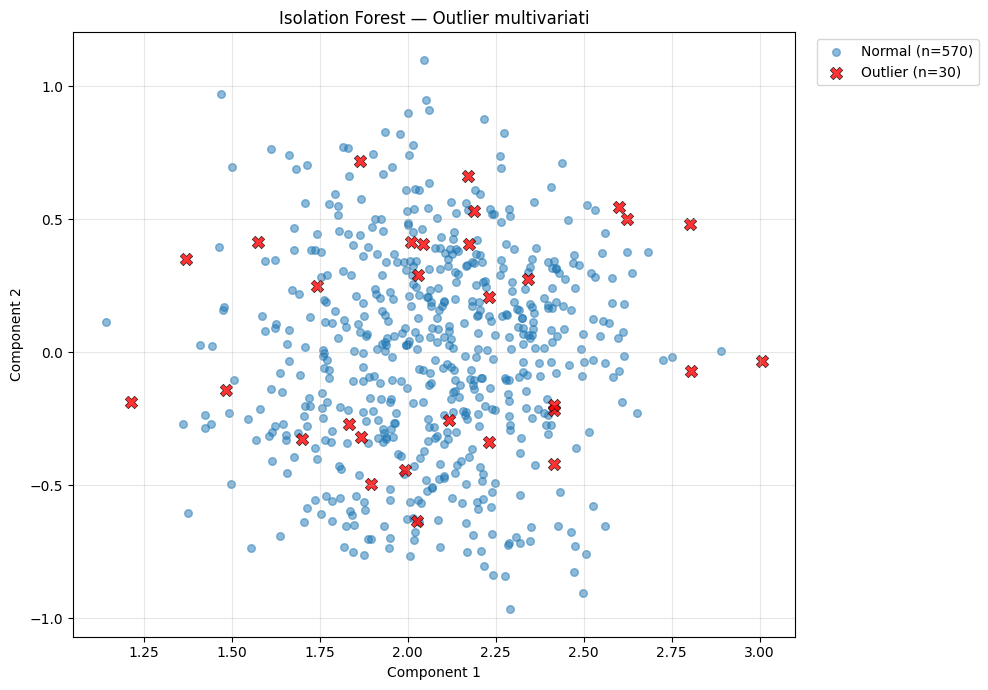

In [348]:
plt.figure(figsize=(10, 7))

normal_mask = save_info["IsoForest_Outlier"] == False
outlier_mask = save_info["IsoForest_Outlier"] == True

plt.scatter(
    save_info.loc[normal_mask, "Component_1"],
    save_info.loc[normal_mask, "Component_2"],
    color="tab:blue", alpha=0.5, s=30,
    label=f"Normal (n={normal_mask.sum()})"
)

plt.scatter(
    save_info.loc[outlier_mask, "Component_1"],
    save_info.loc[outlier_mask, "Component_2"],
    color="red", marker="X", s=80, alpha=0.8,
    edgecolors="black", linewidths=0.5,
    label=f"Outlier (n={outlier_mask.sum()})"
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Isolation Forest — Outlier multivariati")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3.3.4 Confronto finale: K-Means vs DBSCAN vs Isolation Forest

In [349]:
comparison_3way = pd.crosstab(
    [save_info["KMeans_Multivariate_Outlier"], save_info["DBSCAN_Multivariate_Outlier"]],
    save_info["IsoForest_Outlier"],
    rownames=["KMeans Outlier", "DBSCAN Outlier"],
    colnames=["IsoForest Outlier"]
)

print("Confronto outlier tra i tre metodi:\n")
print(comparison_3way)

save_info["outlier_votes"] = (
    save_info["KMeans_Multivariate_Outlier"].astype(int) +
    save_info["DBSCAN_Multivariate_Outlier"].astype(int) +
    save_info["IsoForest_Outlier"].astype(int)
)

print("\n\nConsenso tra metodi (numero di metodi che segnalano outlier):")
print(save_info["outlier_votes"].value_counts().sort_index())

consensus_outliers = save_info[save_info["outlier_votes"] >= 2]
print(f"\nOutlier per consensus (≥2 metodi su 3): {len(consensus_outliers)}")
print(f"Percentuale: {round(len(consensus_outliers) / len(save_info) * 100, 2)}%")

Confronto outlier tra i tre metodi:

IsoForest Outlier              False  True 
KMeans Outlier DBSCAN Outlier              
False          False             540      7
               True               20      3
True           False               9     14
               True                1      6


Consenso tra metodi (numero di metodi che segnalano outlier):
outlier_votes
0    540
1     36
2     18
3      6
Name: count, dtype: int64

Outlier per consensus (≥2 metodi su 3): 24
Percentuale: 4.0%


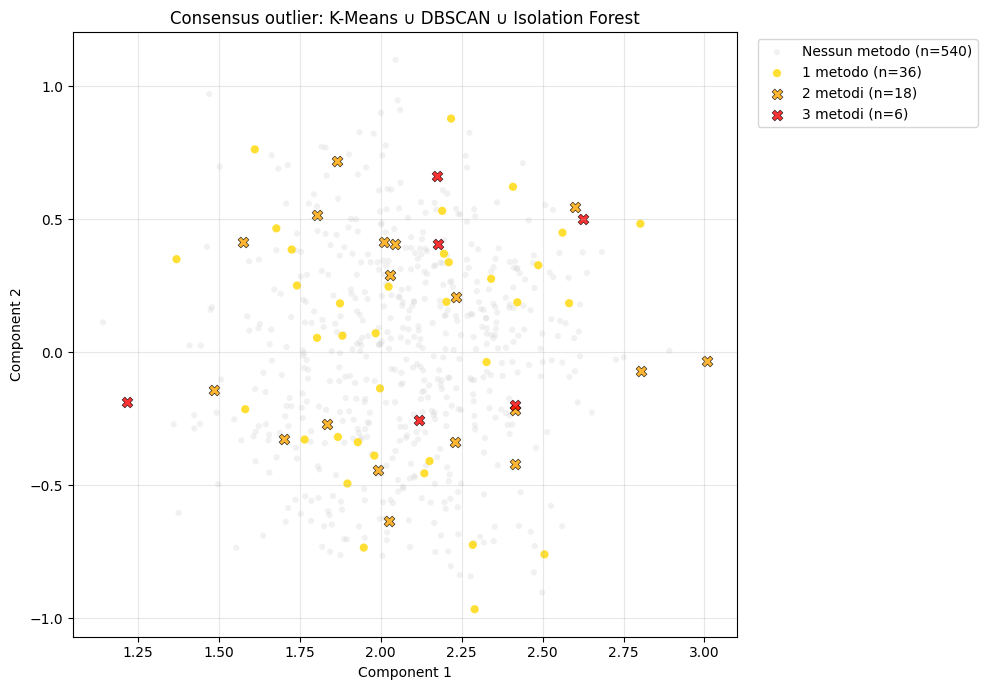

In [350]:
plt.figure(figsize=(10, 7))

vote_colors = {0: "lightgray", 1: "gold", 2: "orange", 3: "red"}

for votes in sorted(save_info["outlier_votes"].unique()):
    mask = save_info["outlier_votes"] == votes
    if votes == 0:
        label = f"Nessun metodo (n={mask.sum()})"
        marker, size, alpha = "o", 20, 0.3
    else:
        label = f"{votes} metod{'o' if votes == 1 else 'i'} (n={mask.sum()})"
        marker = "X" if votes >= 2 else "o"
        size = 60 if votes >= 2 else 35
        alpha = 0.8

    plt.scatter(
        save_info.loc[mask, "Component_1"],
        save_info.loc[mask, "Component_2"],
        color=vote_colors[votes],
        marker=marker, s=size, alpha=alpha, label=label,
        edgecolors="black" if votes >= 2 else "none",
        linewidths=0.5 if votes >= 2 else 0
    )

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Consensus outlier: K-Means ∪ DBSCAN ∪ Isolation Forest")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Riepilogo dell'analisi multivariata

| Metodo | Tipo | Approccio outlier | Vantaggi | Limiti |
|---|---|---|---|---|
| K-Means | Centroid-based | Distanza dal centroide > 95° percentile | Semplice, interpretabile | Soglia arbitraria, cluster forzati |
| DBSCAN | Density-based | Punti noise (label = -1) | Non richiede n. cluster | Fallisce in alta dimensionalità |
| Isolation Forest | Isolation-based | Score di anomalia per isolamento | Robusto in alta dimensionalità, score continuo | Non produce cluster |

L'analisi consensus permette di individuare i profili più robusti: le osservazioni segnalate come outlier da almeno due metodi su tre rappresentano anomalie multi-criterio, riducendo il rischio di falsi positivi legati alle assunzioni di un singolo algoritmo.

#### Identificazione e rimozione degli outlier per consensus

In [351]:
# Outlier segnalati da almeno 2 metodi su 3
consensus_mask = save_info["outlier_votes"] >= 2

outlier_indices = save_info[consensus_mask].index.tolist()

print(f"Indici delle righe outlier (consensus ≥2): {outlier_indices}")
print(f"Totale: {len(outlier_indices)} su {len(save_info)}")

# Mostra il profilo degli outlier
save_info[consensus_mask][
    clustering_features + ["KMeans_Multivariate_Outlier", "DBSCAN_Multivariate_Outlier", "IsoForest_Outlier", "outlier_votes"]
].sort_index()

Indici delle righe outlier (consensus ≥2): [31, 40, 42, 43, 70, 92, 113, 161, 172, 193, 227, 234, 321, 359, 371, 422, 428, 430, 431, 473, 477, 505, 547, 576]
Totale: 24 su 600


,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Engagement_Score,Tenure_Instability,KMeans_Multivariate_Outlier,DBSCAN_Multivariate_Outlier,IsoForest_Outlier,outlier_votes
31,35,Male,Single,3,4,Marketing,Research & Development,Sales Executive,2,Travel_Rarely,...,9,5,1,3,1.960000,9.066,True,False,True,2
40,18,Female,Divorced,24,5,Marketing,Sales,Laboratory Technician,1,Travel_Rarely,...,1,0,5,1,2.850000,0.149,True,False,True,2
42,25,Male,Divorced,5,5,Life Sciences,Research & Development,Sales Representative,3,Travel_Frequently,...,10,0,2,1,3.030000,1.408,False,True,True,2
43,35,Male,Married,1,1,Medical,Research & Development,Sales Executive,1,Travel_Rarely,...,13,11,0,1,2.734817,1.199,True,False,True,2
70,21,Male,Married,6,1,Life Sciences,Sales,Manager,5,Travel_Rarely,...,15,0,3,2,2.840000,0.802,True,False,True,2
92,46,Male,Married,5,1,Life Sciences,Sales,Sales Representative,2,Travel_Frequently,...,0,12,7,0,3.100000,-0.051,True,True,True,3
113,24,Male,Single,3,2,Life Sciences,Research & Development,Sales Executive,1,Travel_Frequently,...,1,10,3,3,1.680000,-0.019,True,True,True,3
161,34,Female,Divorced,1,3,Medical,Research & Development,Research Scientist,2,Travel_Rarely,...,10,7,7,5,3.570000,10.025,True,False,True,2
172,25,Male,Single,10,5,Life Sciences,Sales,Sales Executive,4,Travel_Rarely,...,10,6,5,4,2.490000,3.291,False,True,True,2
193,36,Female,Married,2,3,Life Sciences,Research & Development,Manager,1,Travel_Frequently,...,0,4,7,6,2.660000,0.017,True,False,True,2
